## Comprehensive Exploratory Data Analysis

This notebook performs a comprehensive EDA on customer churn including:
- Data cleaning and pre-processing
- Basic EDA
- Univariate, Bivariate & Multivariate Analysis

The aim is to analylyze and learn maximum about the data and most methods of EDA have been completed.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
confusion_matrix, roc_curve, classification_report)
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')

## Set Visualization & Display Settings

In [2]:
# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Exploratory Data Analysis

In [3]:
# Load data
df = pd.read_csv('Code/data/churn.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
# Data shape
print(f'Dataset Shape: {df.shape}')
print("\n" + "=" * 50 + "\n")

# Missing values
print("Missing Values: ")
print(df.isnull().sum())
print("\n" + "=" * 50 + "\n")

# Check for duplicates
print(f'Duplicate Rows: {df.duplicated()}')
print('\n' + '=' * 50 + '\n')

# Data Types
print('Data Types: ')
print(df.dtypes)
print('\n' + '=' * 50 + '\n')

Dataset Shape: (10000, 14)


Missing Values: 
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Duplicate Rows: 0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


Data Types: 
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object




In [5]:
# Data info
# Missing values and datatypes in 1 place
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
# Drop unnecessary columns
df_clean = df.drop(columns= ['RowNumber', 'CustomerId', 'Surname'])

print('Cleaned Dataset shape: ', df_clean.shape)
print('Remaining columns: ', df_clean.columns.to_list())

Cleaned Dataset shape:  (10000, 11)
Remaining columns:  ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [7]:
# Basic info (cleaned dataset)
print('Dataset info: ')
df_clean.info()
print('\n' + '=' * 50 + '\n')

# Statistical Summary
print('Statistical Summary: ')
df_clean.describe()

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


Statistical Summary: 


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Check target variable distribution
print('Churn Distribution: ')
print(df_clean['Exited'].value_counts())
print('\nChurn Percentage: ')
print(df_clean['Exited'].value_counts(normalize= True) * 100)

Churn Distribution: 
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage: 
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [9]:
# Separate numerical & categorical features
numerical_features = df_clean.select_dtypes(include= ['int64', 'float64']).columns.tolist()
categorical_features = df_clean.select_dtypes(include= ['object']).columns.tolist()

print('Numrical Features: ', numerical_features)
print('Categorical Features: ', categorical_features)

Numrical Features:  ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Categorical Features:  ['Geography', 'Gender']


## Univariate Analysis

### Target Variable (churn)

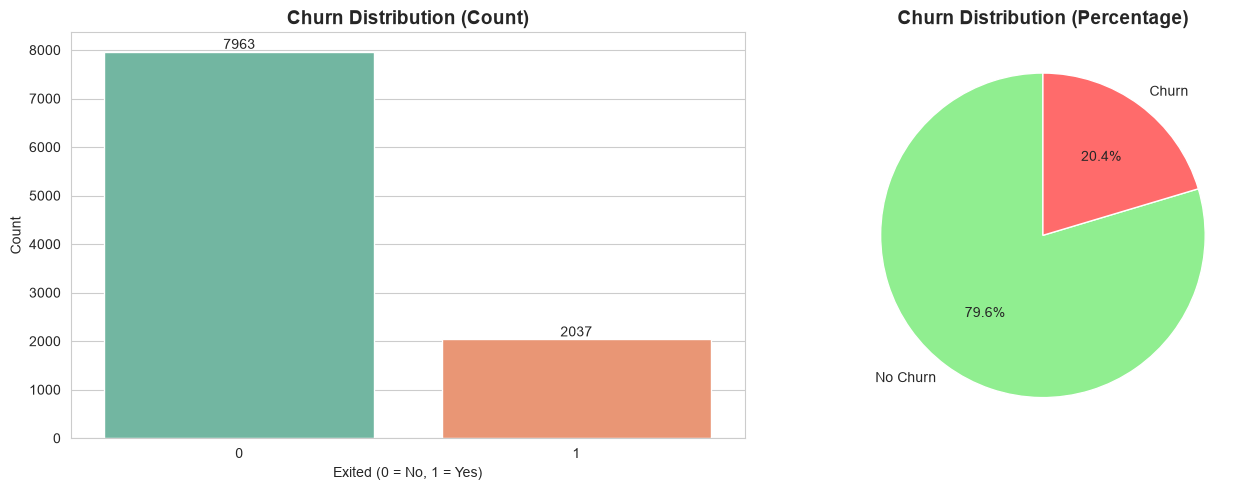

In [10]:
# Visualize target variable
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Count plot
sns.countplot(data = df_clean, x = 'Exited', palette = 'Set2', ax = axes[0])
axes[0].set_title("Churn Distribution (Count)", fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Exited (0 = No, 1 = Yes)')
axes[0].set_ylabel("Count")
for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart
churn_counts = df_clean['Exited'].value_counts()
axes[1].pie(churn_counts, labels = ['No Churn', 'Churn'], autopct = '%1.1f%%',
            colors = ['#90EE90', '#FF6B6B'], startangle = 90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

### Numerical Features Distribution

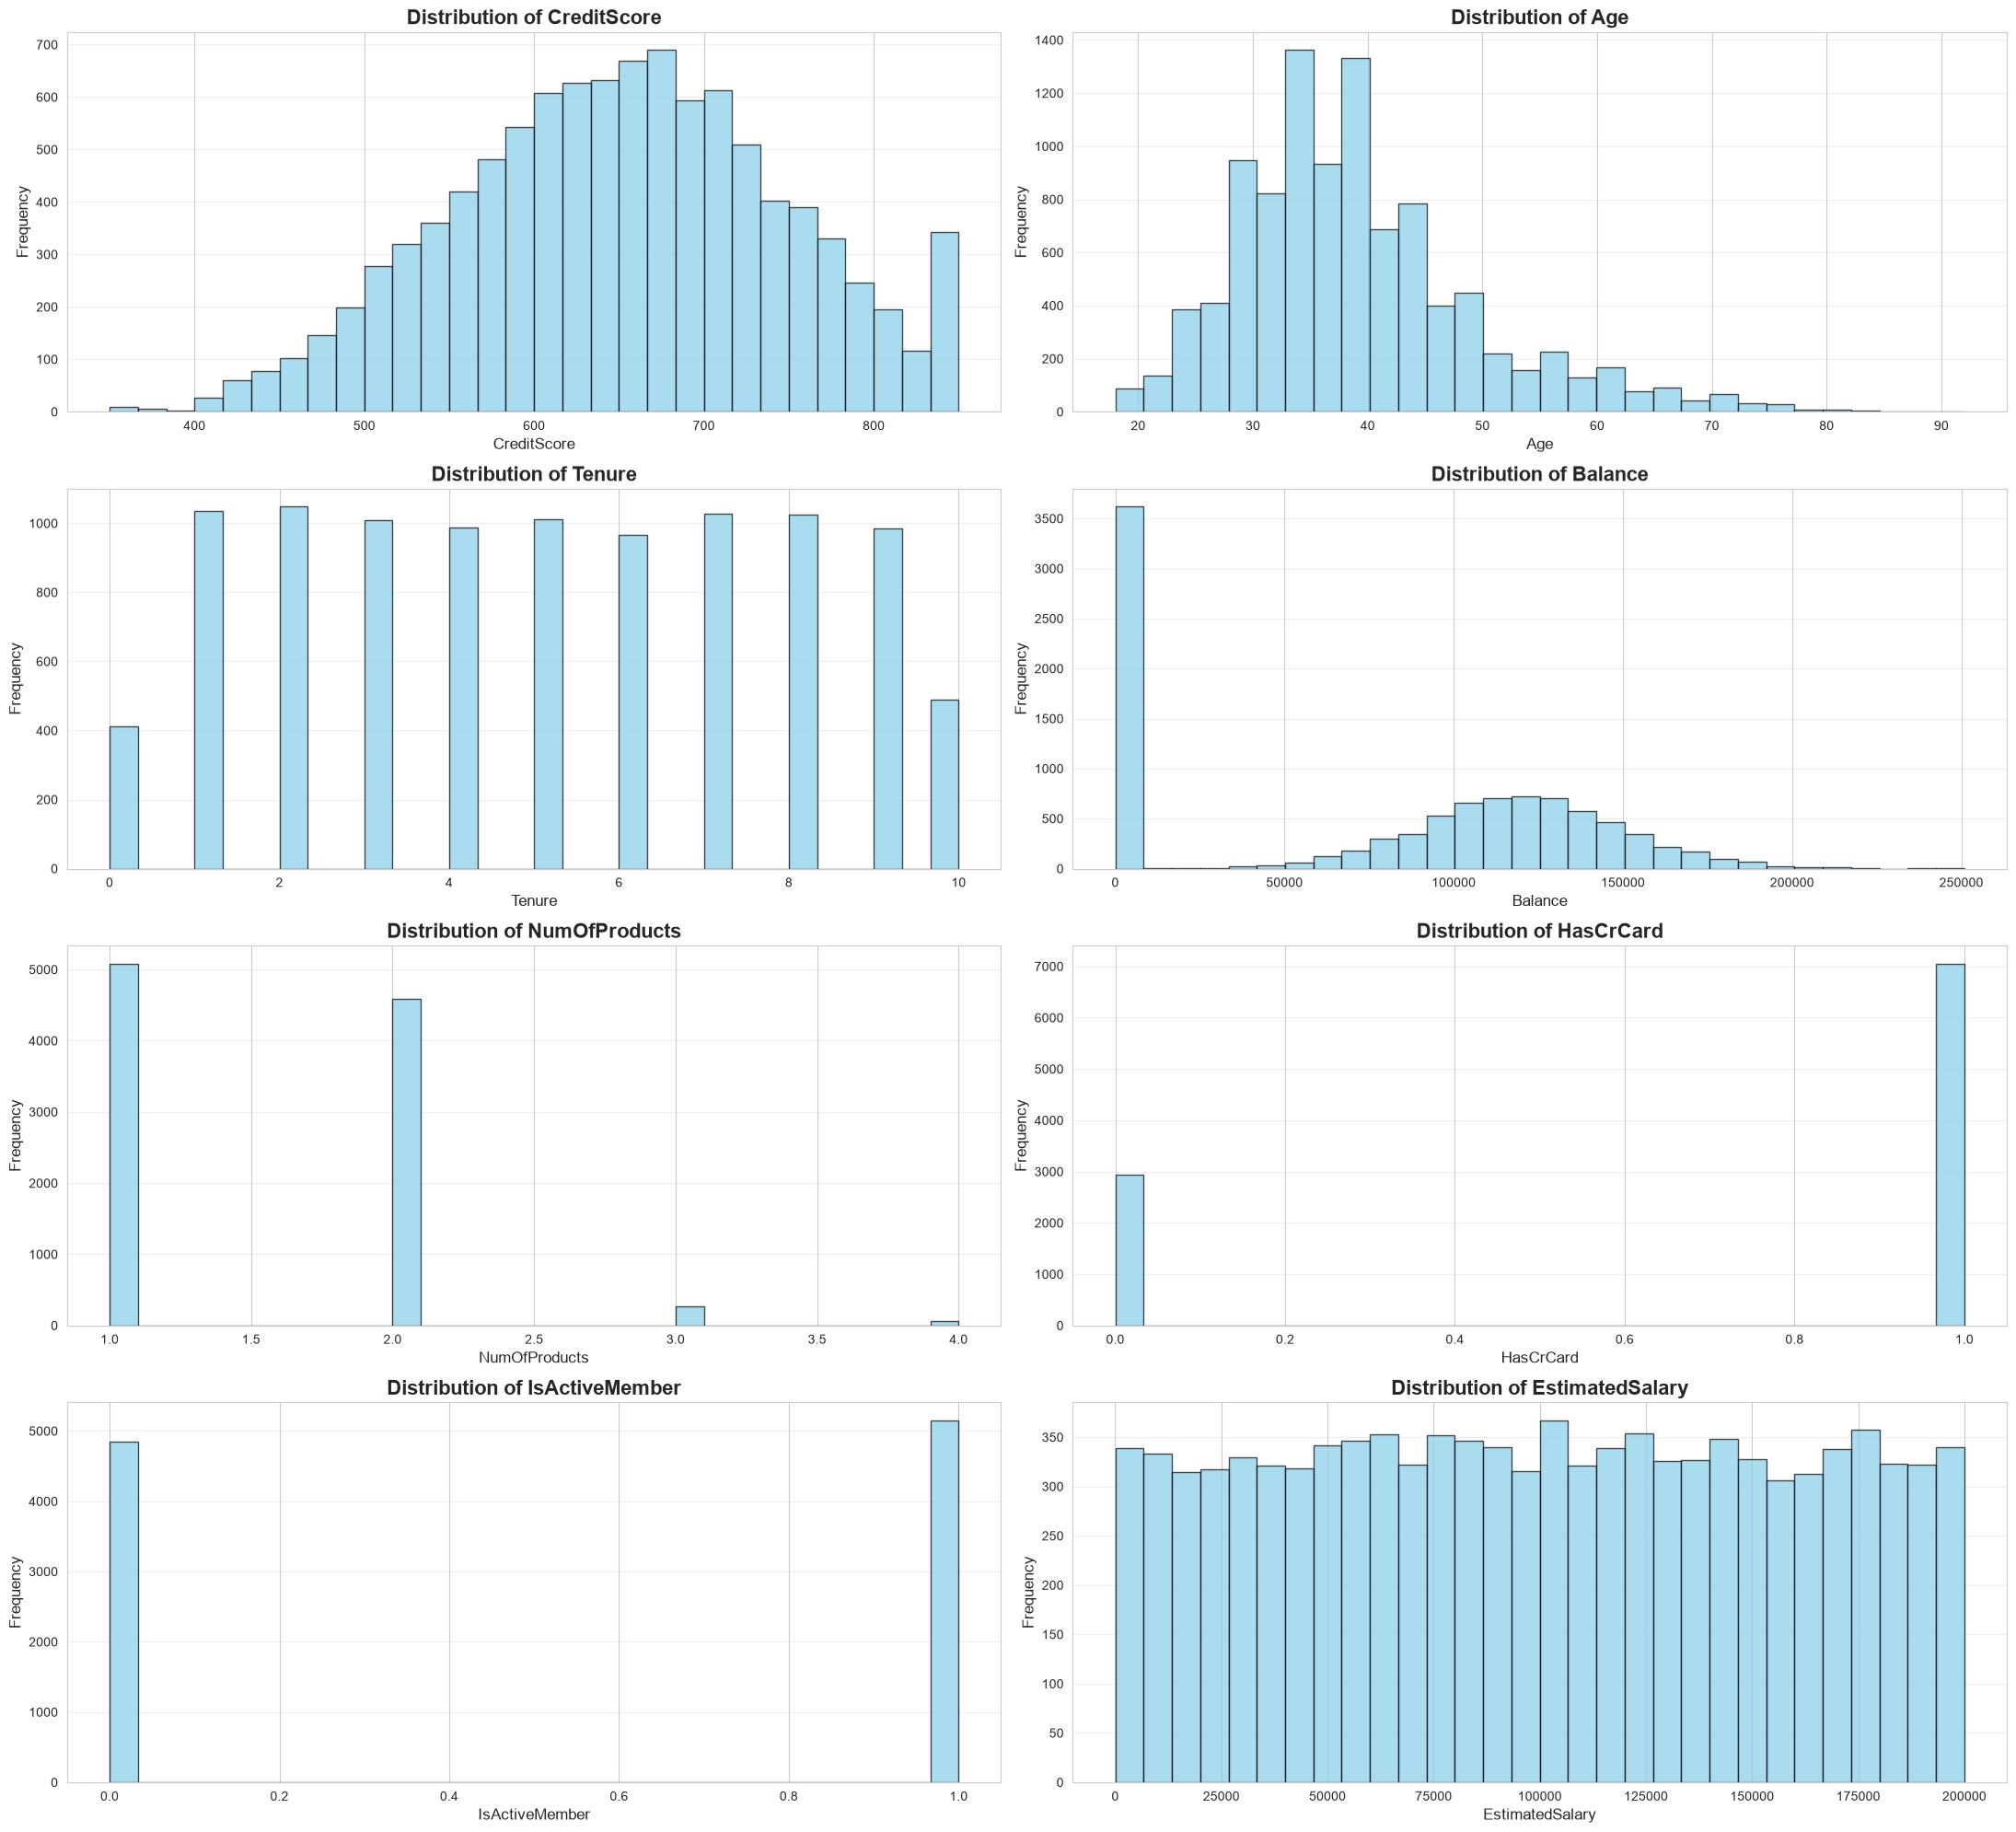

In [11]:
# Distribution of numerical features (excluding Exited)
numerical_cols = [col for col in numerical_features if col != 'Exited']

fig, axes = plt.subplots(4, 2, figsize = (22, 20))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df_clean[col], bins = 30, color = 'skyblue', edgecolor = 'black', alpha = 0.7)
    axes[idx].set_title(f"Distribution of {col}", fontsize = 16, fontweight = 'bold')
    axes[idx].set_xlabel(col, fontsize = 12)
    axes[idx].set_ylabel('Frequency', fontsize = 12)
    axes[idx].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

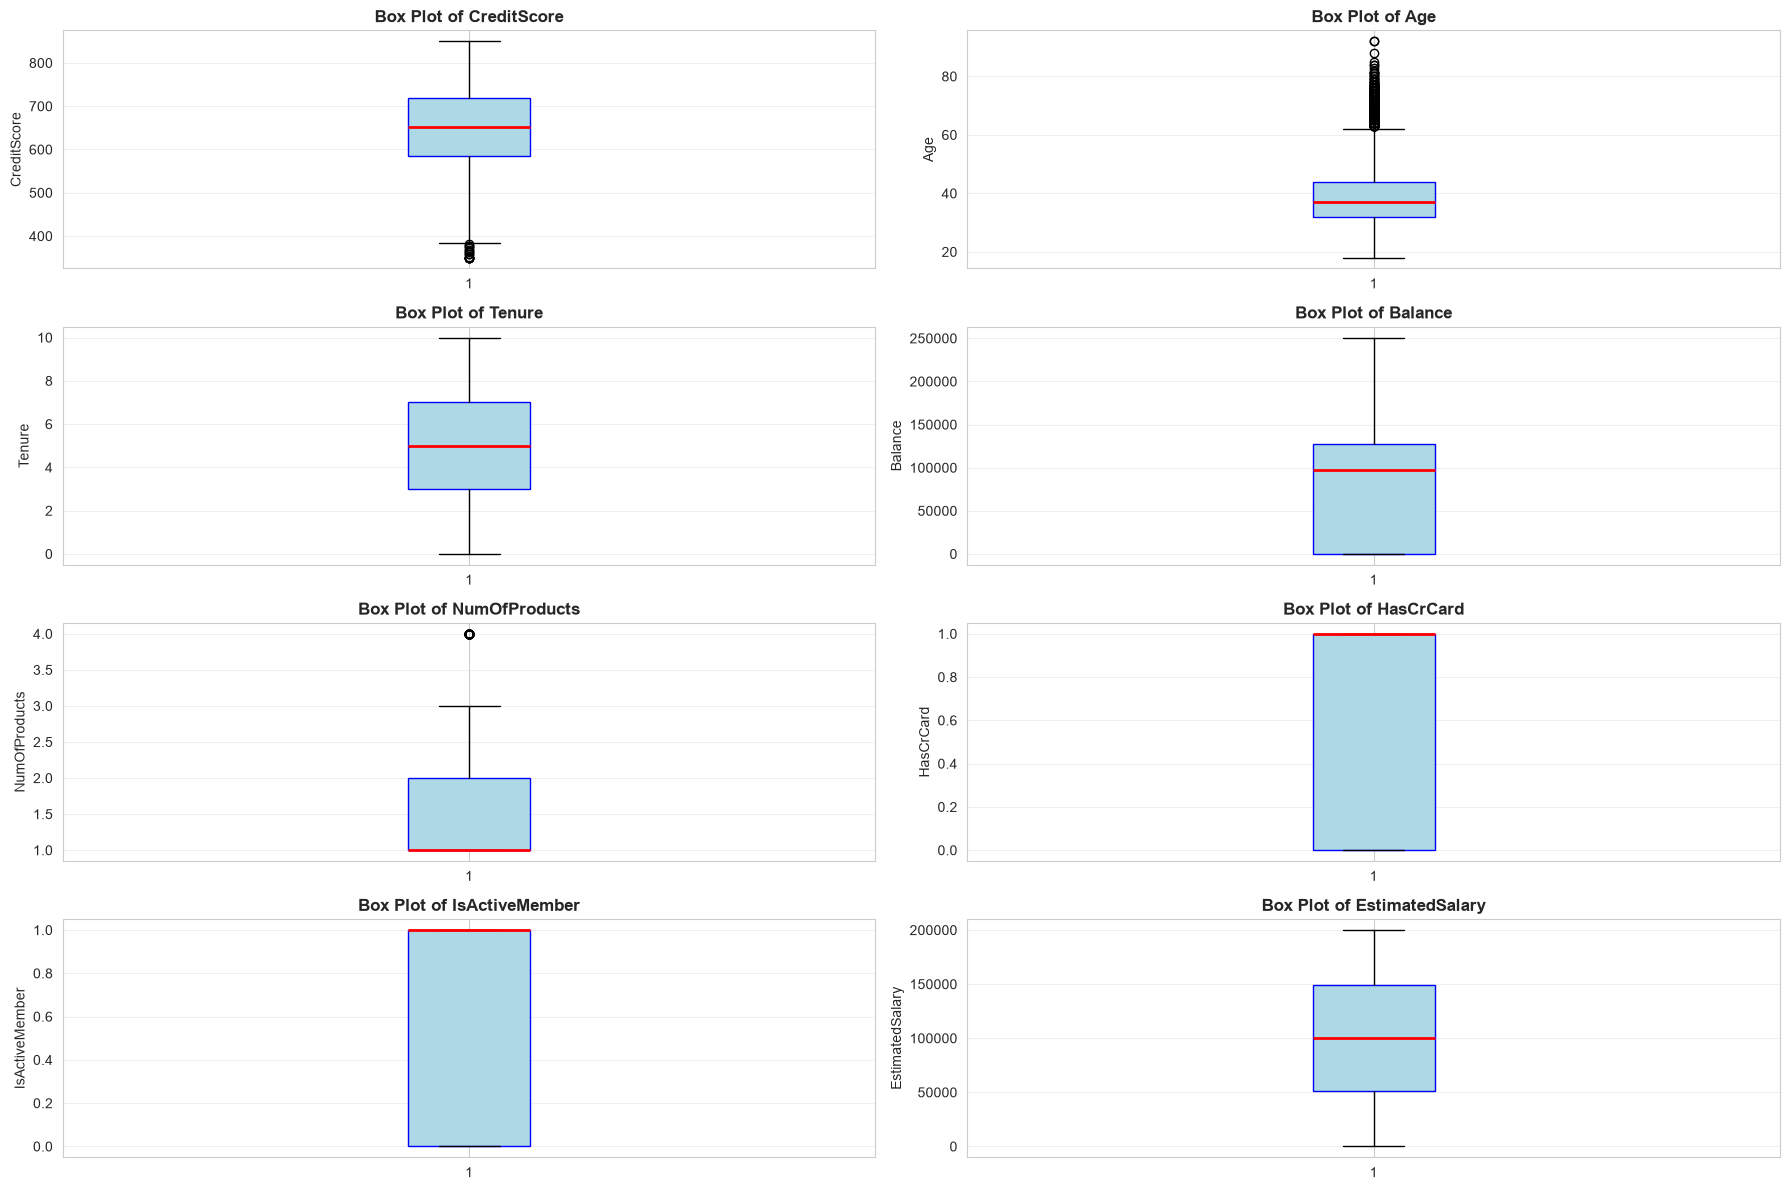

In [12]:
# Box plots to detect outliers in numerical features
fig, axes = plt.subplots(4, 2, figsize = (18, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df_clean[col].dropna(), vert = True, patch_artist = True,
                     boxprops = dict(facecolor = 'lightblue', color = 'blue'),
                     medianprops = dict(color = 'red', linewidth = 2))
    axes[idx].set_title(f'Box Plot of {col}', fontsize = 12, fontweight = 'bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

### Categorical Features Distribution

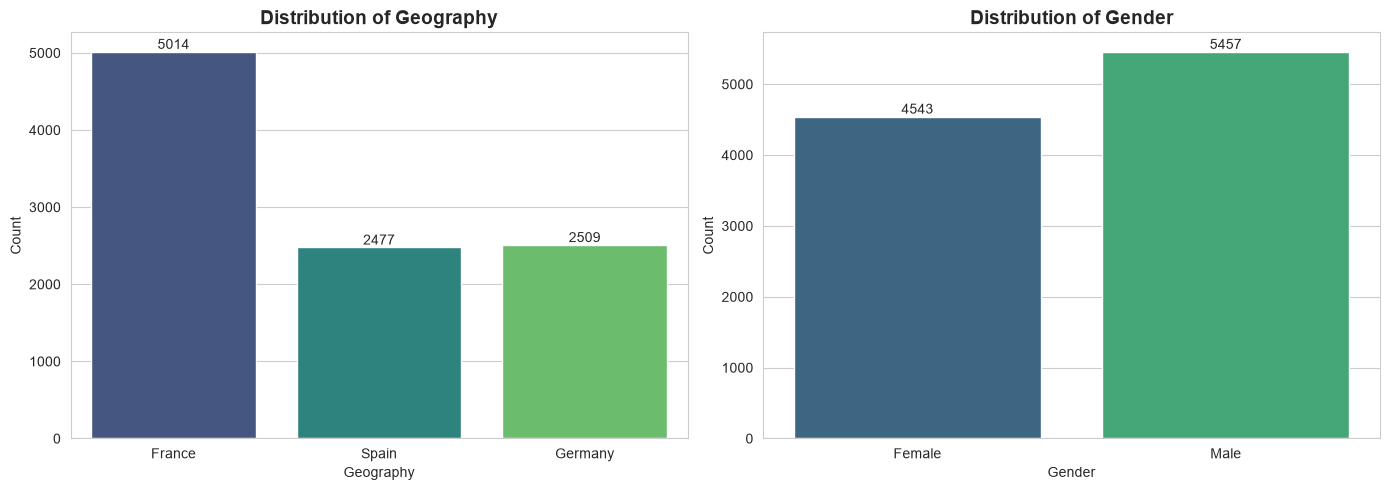

In [13]:
# Distribution of categorical features
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

for idx, col in enumerate(categorical_features):
    sns.countplot(data = df_clean, x = col, palette = 'viridis', ax = axes[idx])
    axes[idx].set_title(f'Distribution of {col}', fontsize = 14, fontweight = 'bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    for container in axes[idx].containers:
        axes[idx].bar_label(container)

plt.tight_layout()
plt.show()

### Bivariate Analysis

### Numerical Features vs Churn

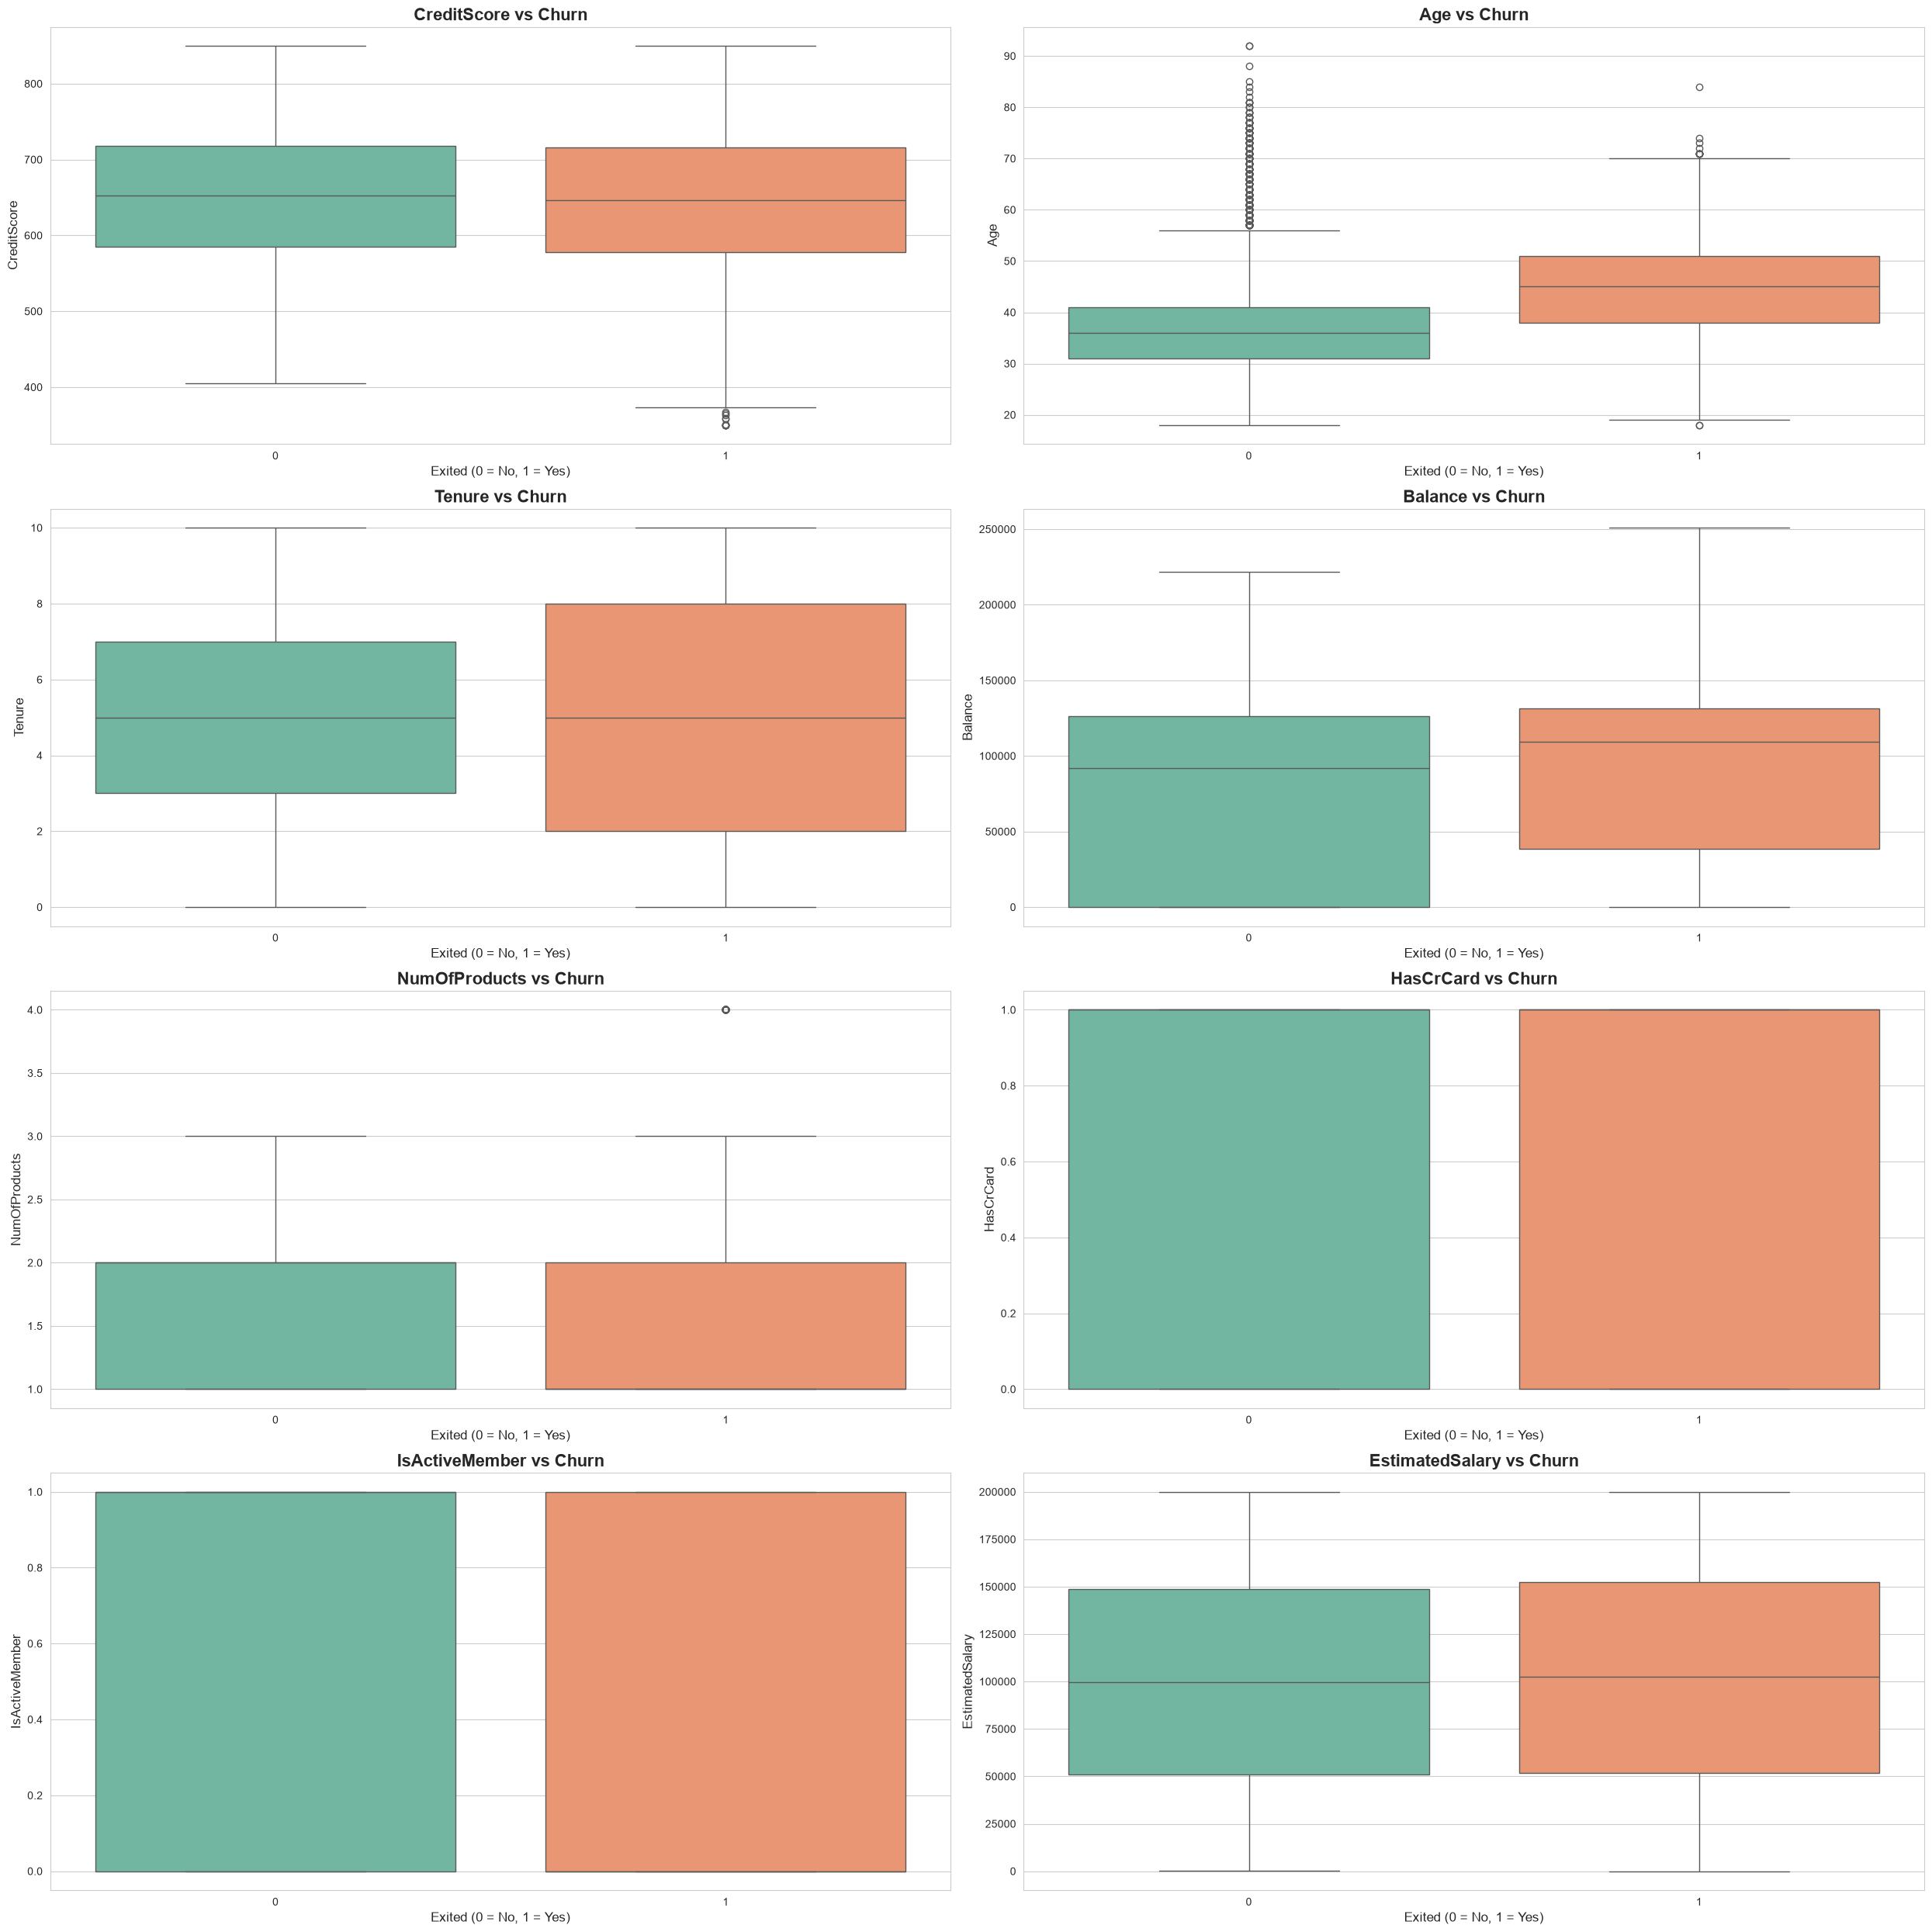

In [14]:
# Box plot: Numerical Features by Churn status
fig, axes = plt.subplots(4, 2, figsize = (25, 25))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data = df_clean, x = 'Exited', y = col, palette = 'Set2', ax = axes[idx])
    axes[idx].set_title(f'{col} vs Churn', fontsize = 16, fontweight = 'bold')
    axes[idx].set_ylabel(col, fontsize = 12)
    axes[idx].set_xlabel('Exited (0 = No, 1 = Yes)', fontsize = 12)


plt.tight_layout()
plt.show()

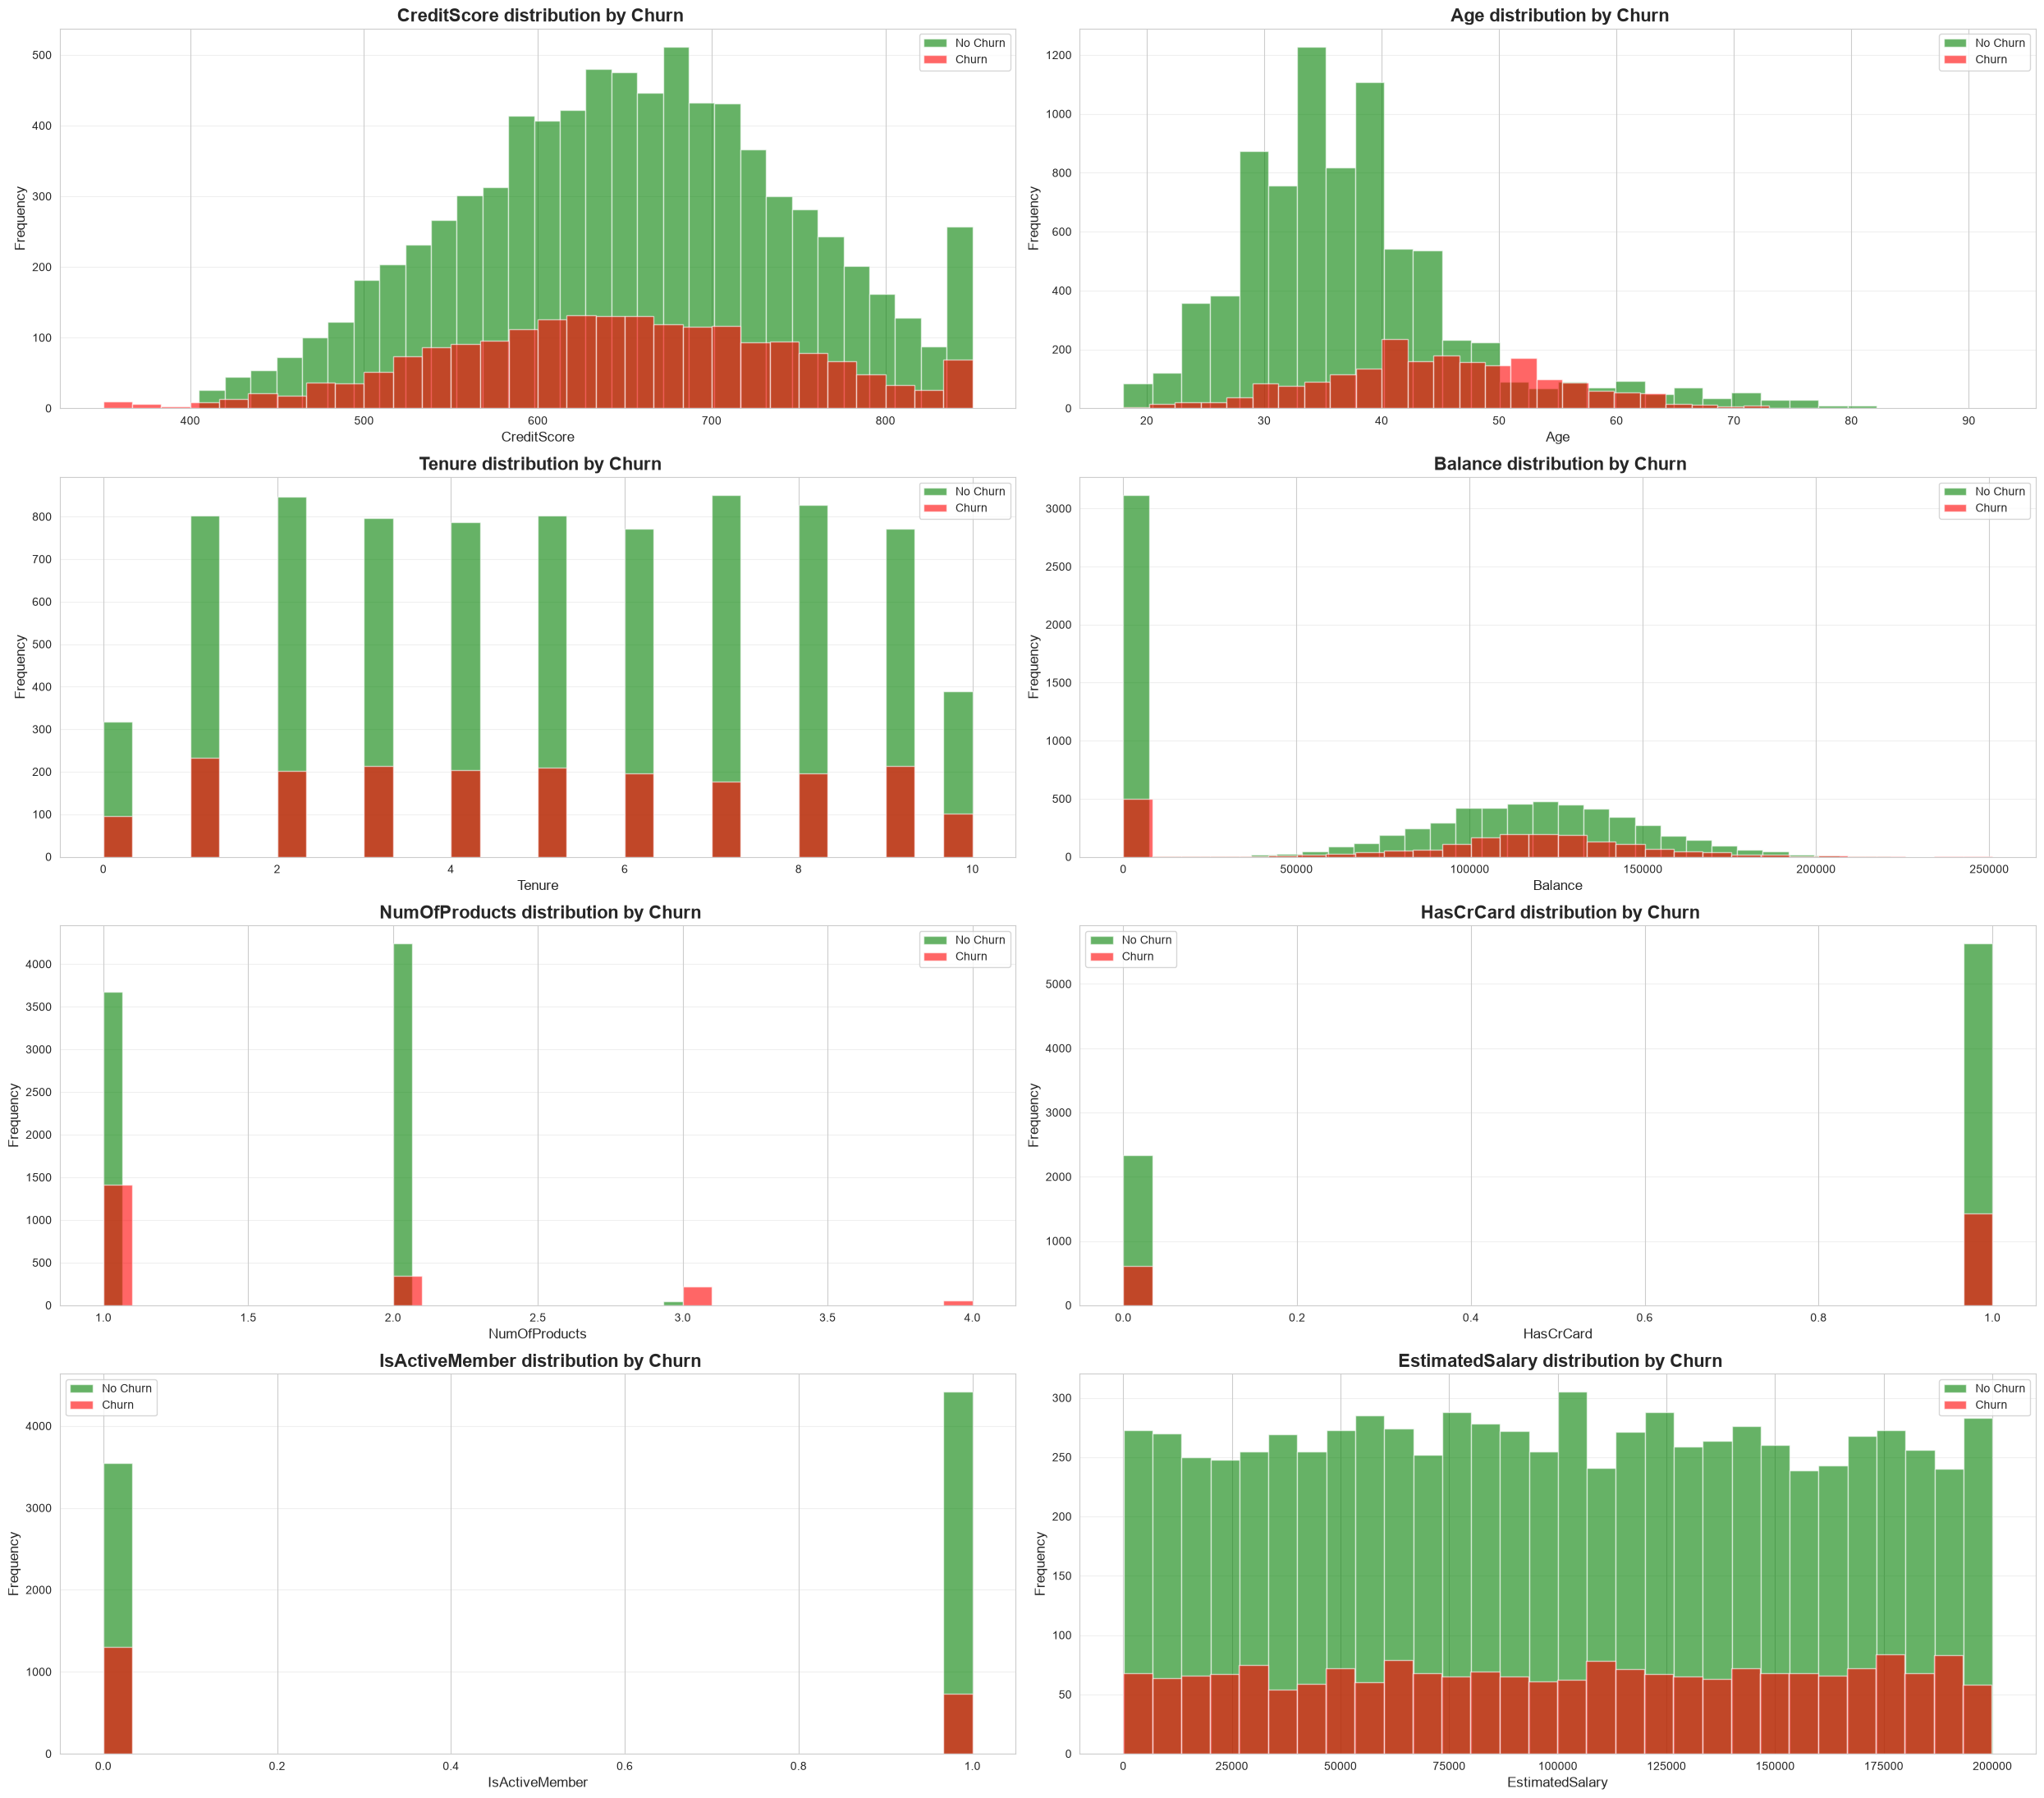

In [15]:
# Distribution Plots: Numerical Features vs Churn Status
fig, axes = plt.subplots(4, 2, figsize = (25, 22))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    df_clean[df_clean['Exited'] == 0][col].hist(bins = 30, alpha = 0.6, label = 'No Churn', color = 'green', ax = axes[idx])
    df_clean[df_clean['Exited'] == 1][col].hist(bins = 30, alpha = 0.6, label = 'Churn', color = 'red', ax = axes[idx])
    axes[idx].set_title(f' {col} distribution by Churn', fontweight = 'bold', fontsize = 16)
    axes[idx].set_ylabel('Frequency', fontsize = 12)
    axes[idx].set_xlabel(col, fontsize = 12)
    axes[idx].legend()
    axes[idx].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

### Categorical Features vs Churn

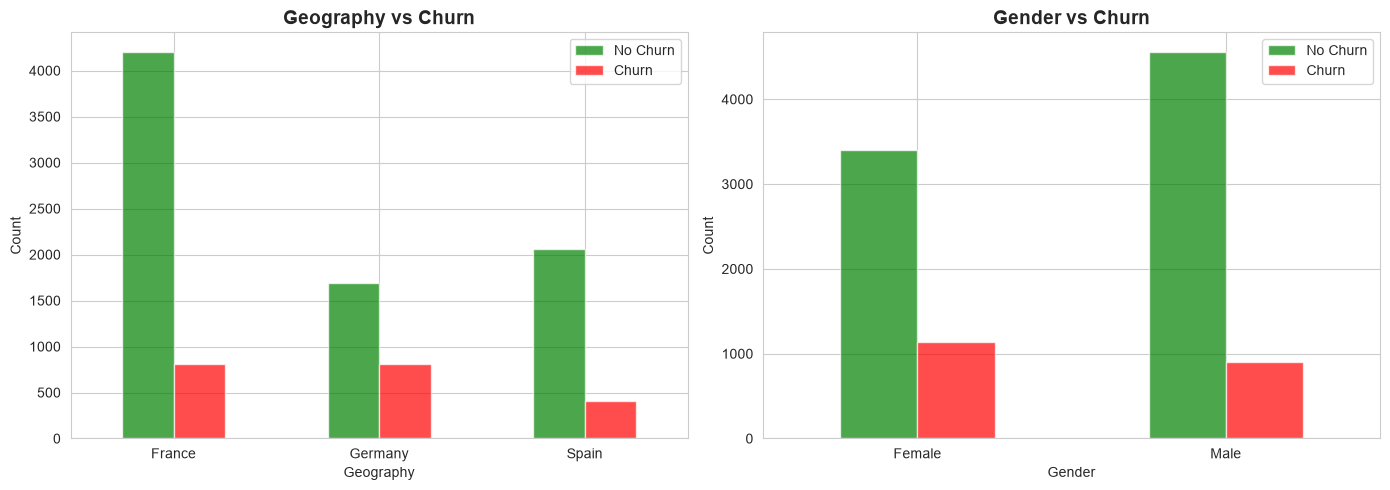

In [16]:
# Categorical features vs Churn
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

for idx, col in enumerate(categorical_features):
    churn_data = df_clean.groupby([col, 'Exited']).size().unstack(fill_value= 0)
    churn_data.plot(kind = 'bar', stacked = False, ax = axes[idx], color = ['green', 'red'], alpha = 0.7)
    axes[idx].set_title(f'{col} vs Churn', fontsize = 14, fontweight = 'bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend(['No Churn', 'Churn'])
    axes[idx].tick_params(axis = 'x', rotation = 0)

plt.tight_layout()
plt.show()

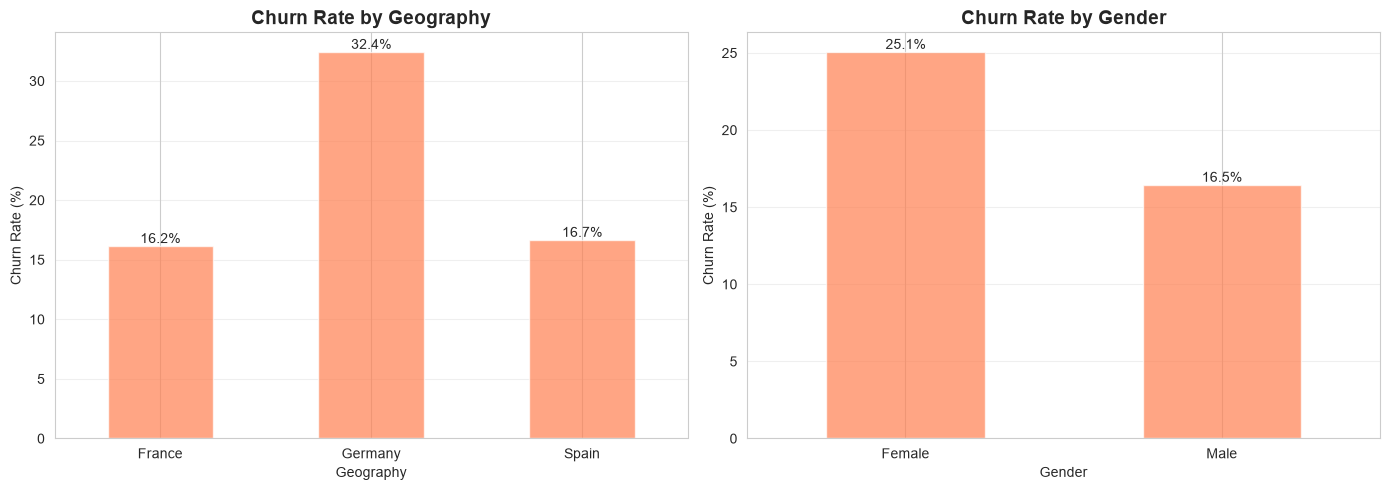

In [17]:
# Churn Rate by Categorical Features
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
for idx, col in enumerate(categorical_features):
    churn_rate = df_clean.groupby(col)['Exited'].mean() * 100
    churn_rate.plot(kind = 'bar', ax = axes[idx], color = 'coral', alpha = 0.7)
    axes[idx].set_title(f'Churn Rate by {col}', fontsize = 14, fontweight = 'bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].tick_params(axis = 'x', rotation = 0)
    axes[idx].grid(axis = 'y', alpha = 0.3)

    # Add value labels on bars
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt = '%.1f%%')

plt.tight_layout()
plt.show()

### Correlation Analysis

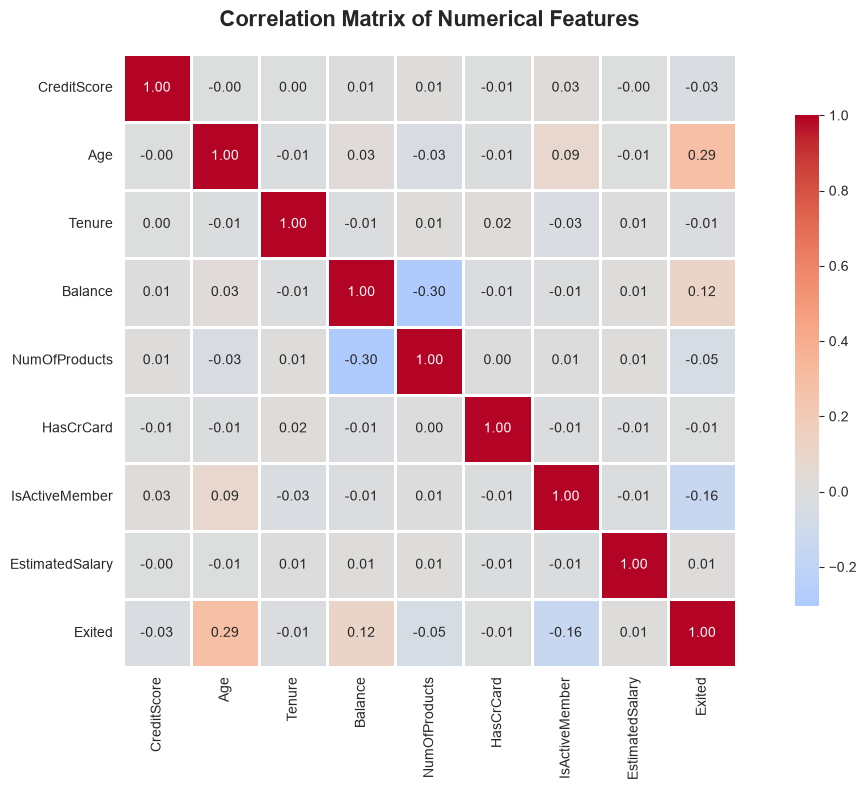

In [18]:
# Correlation Matrix
plt.figure(figsize = (12, 8))
correlation_matrix = df_clean[numerical_features].corr()
sns.heatmap(correlation_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0, 
            square = True, linewidths = 1, cbar_kws= {'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize = 16, fontweight = 'bold', pad = 20)
plt.tight_layout()
plt.show()

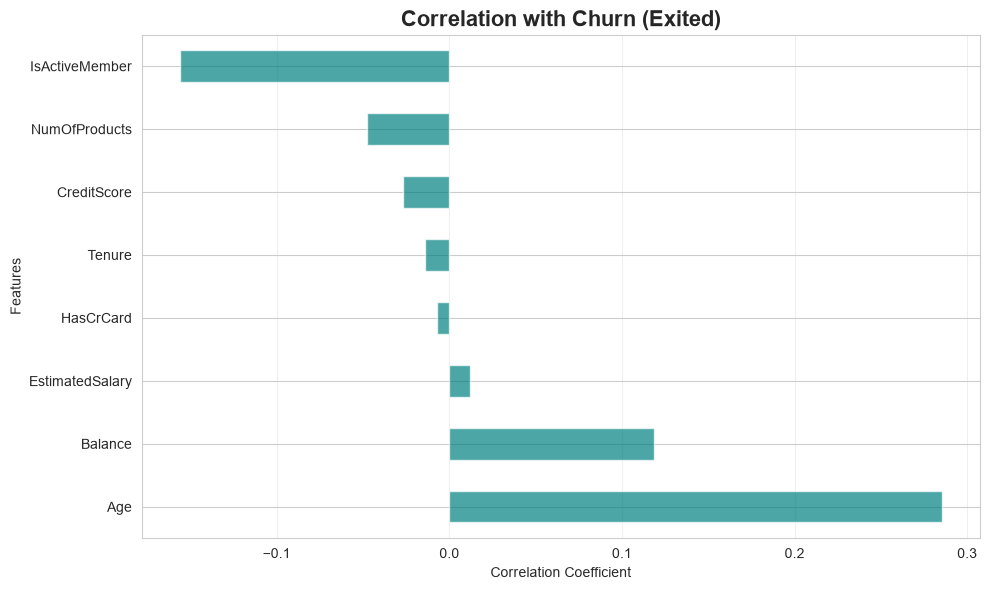


Correlation Coefficient: 
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


In [19]:
# Correlation with target variable (Exited)
plt.figure(figsize = (10, 6))
correlation_with_target = df_clean[numerical_features].corr()['Exited'].sort_values(ascending = False)
correlation_with_target  = correlation_with_target.drop('Exited')

correlation_with_target.plot(kind = 'barh', color = 'teal', alpha = 0.7)
plt.title('Correlation with Churn (Exited)', fontsize = 16, fontweight = 'bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.show()

print('\nCorrelation Coefficient: ')
print(correlation_with_target)

## Bivariate Analysis

### Pairplot - Key Features

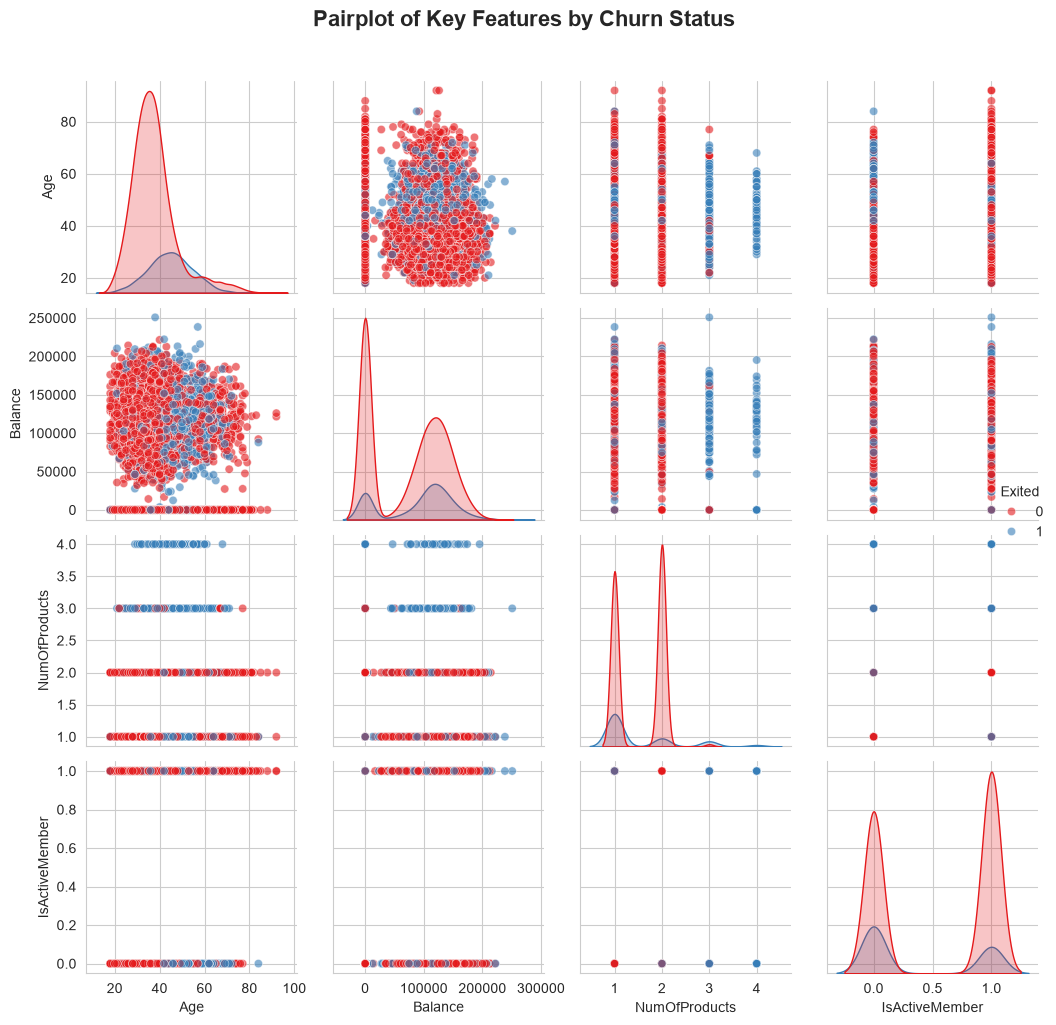

In [20]:
# Pairplot for key features with highest correlation to churn
key_features = ['Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Exited']
sns.pairplot(df_clean[key_features], hue = 'Exited', palette = 'Set1', diag_kind = 'kde',
            plot_kws = {'alpha': 0.6}, height = 2.5)
plt.suptitle('Pairplot of Key Features by Churn Status', y = 1.02, fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

### Age vs Balance by Geography and Gender

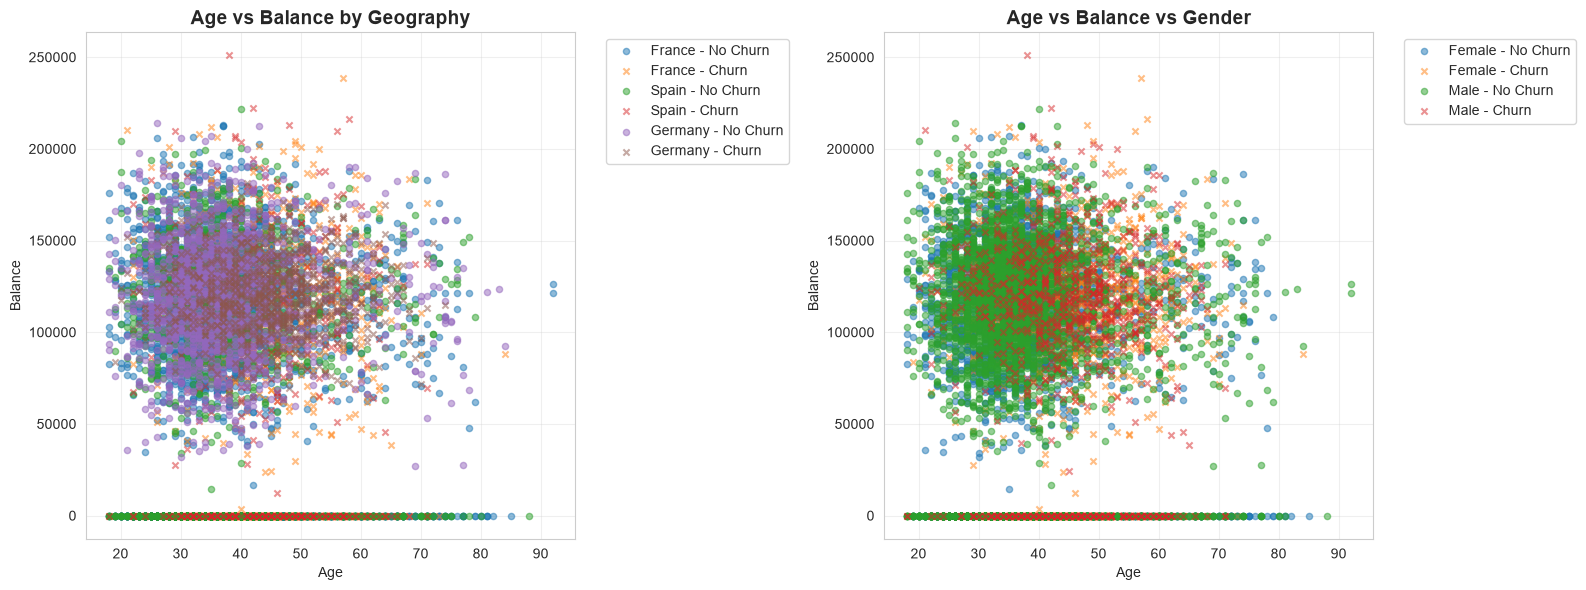

In [21]:
# Scatter Plot: Age vs Balance by Geography and Churn
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# By Geography
for geography in df_clean['Geography'].unique():
    data = df_clean[df_clean['Geography'] == geography]
    axes[0].scatter(data[data['Exited'] == 0]['Age'],
                    data[data['Exited'] == 0]['Balance'],
                    alpha = 0.5, label = f'{geography} - No Churn', s = 20)
    axes[0].scatter(data[data['Exited'] == 1]['Age'],
                    data[data['Exited'] == 1]['Balance'],
                    alpha = 0.5, marker = 'x', label = f'{geography} - Churn', s = 20)

axes[0].set_title('Age vs Balance by Geography', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Balance')
axes[0].legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
axes[0].grid(alpha = 0.3)

# By Gender
for gender in df_clean['Gender'].unique():
    data = df_clean[df_clean['Gender'] == gender]
    axes[1].scatter(data[data['Exited'] == 0]['Age'],
                    data[data['Exited'] == 0]['Balance'],
                    alpha = 0.5, label = f'{gender} - No Churn', s = 20)
    axes[1].scatter(data[data['Exited'] == 1]['Age'],
                    data[data['Exited'] == 1]['Balance'],
                    alpha = 0.5, marker = 'x', label = f'{gender} - Churn', s = 20)

axes[1].set_title('Age vs Balance vs Gender', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Balance')
axes[1].legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### Churn Rate by Multiple Dimension

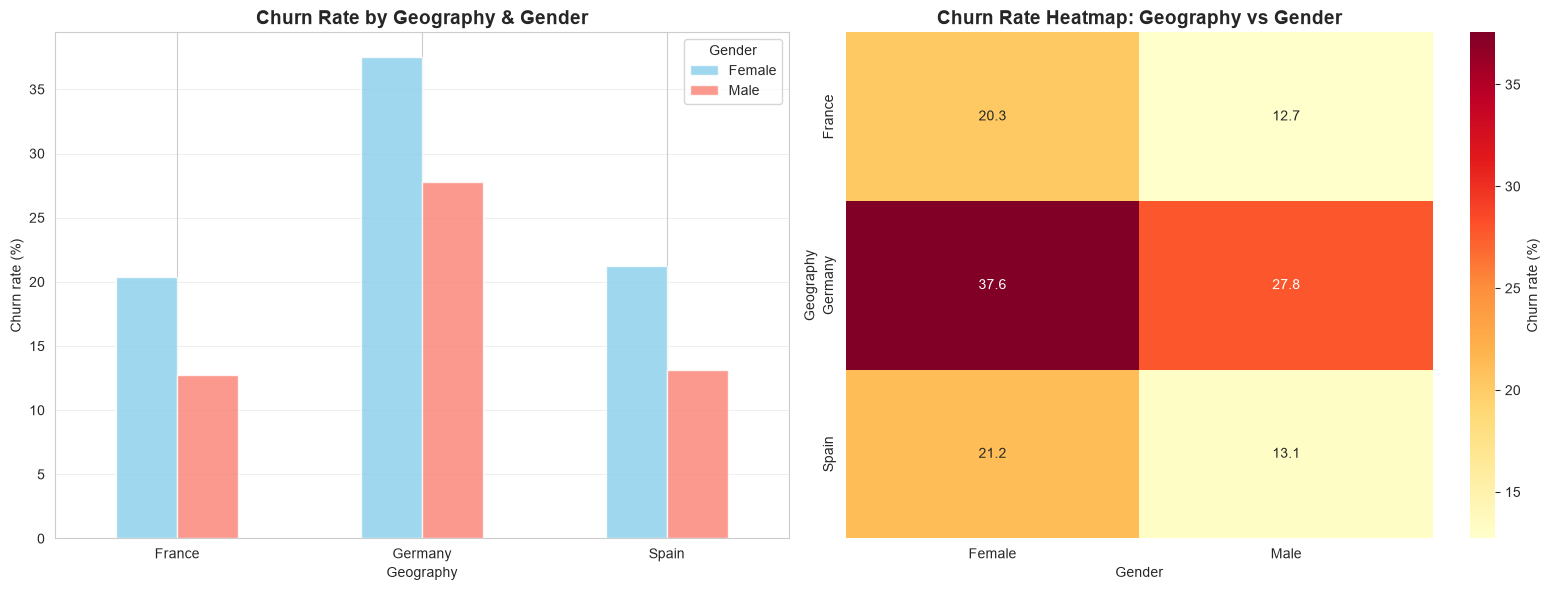

In [22]:
# Churn Rate by Geography and Gender
churn_geo_gender = df_clean.groupby(['Geography', 'Gender'])['Exited'].mean() * 100
churn_geo_gender = churn_geo_gender.unstack()

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Grouped bar chart
churn_geo_gender.plot(kind = 'bar', ax = axes[0], color = ['skyblue', 'salmon'], alpha = 0.8)
axes[0].set_title('Churn Rate by Geography & Gender', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Geography')
axes[0].set_ylabel('Churn rate (%)')
axes[0].legend(title = 'Gender')
axes[0].tick_params(axis = 'x', rotation = 0)
axes[0].grid(axis = 'y', alpha = 0.3)

# Heatmap
sns.heatmap(churn_geo_gender, annot = True, fmt = '.1f', cmap = 'YlOrRd', ax = axes[1], cbar_kws= {'label': 'Churn rate (%)'})
axes[1].set_title('Churn Rate Heatmap: Geography vs Gender', fontsize= 14, fontweight = 'bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Geography')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

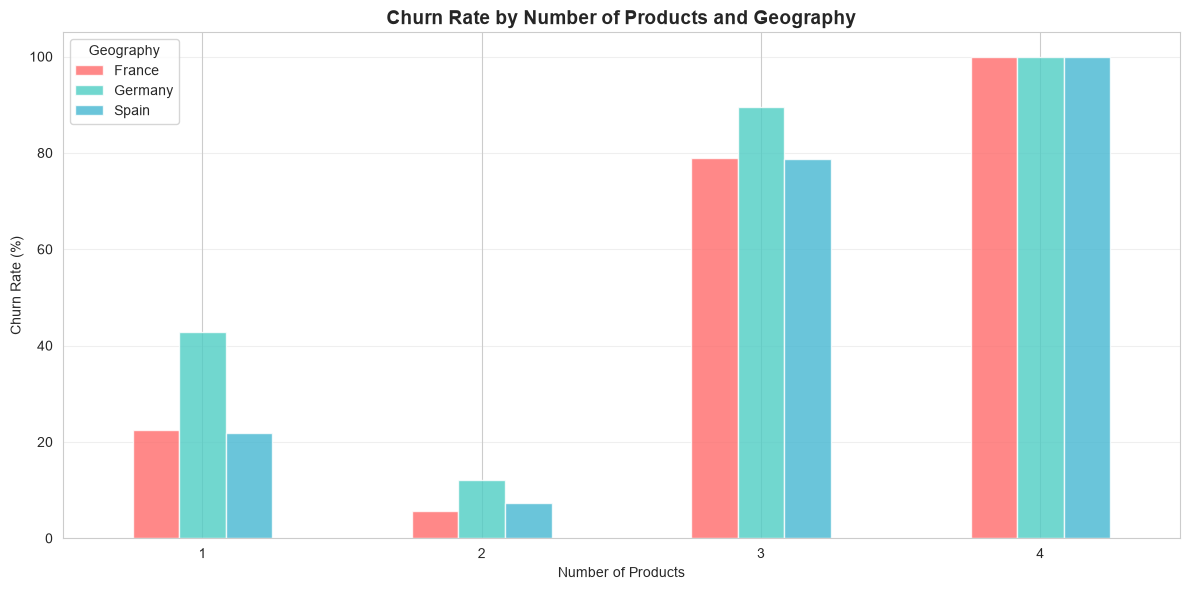


Churn Rate by Number of Products & Geography: 
Geography          France     Germany       Spain
NumOfProducts                                    
1               22.434368   42.846553   21.867322
2                5.703422   12.115385    7.354184
3               78.846154   89.583333   78.787879
4              100.000000  100.000000  100.000000


In [23]:
# Churn Rate by NumOfProducts and Geography
churn_products_geo = df_clean.groupby(['NumOfProducts', 'Geography'])['Exited'].mean() * 100
churn_products_geo = churn_products_geo.unstack()

plt.figure(figsize = (12, 6))
churn_products_geo.plot(kind = 'bar', color = ['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha = 0.8)
plt.title('Churn Rate by Number of Products and Geography', fontsize = 14, fontweight = 'bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Number of Products')
plt.legend(title = 'Geography')
plt.xticks(rotation = 0)
plt.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

print("\nChurn Rate by Number of Products & Geography: ")
print(churn_products_geo)

### Age Group Analysis

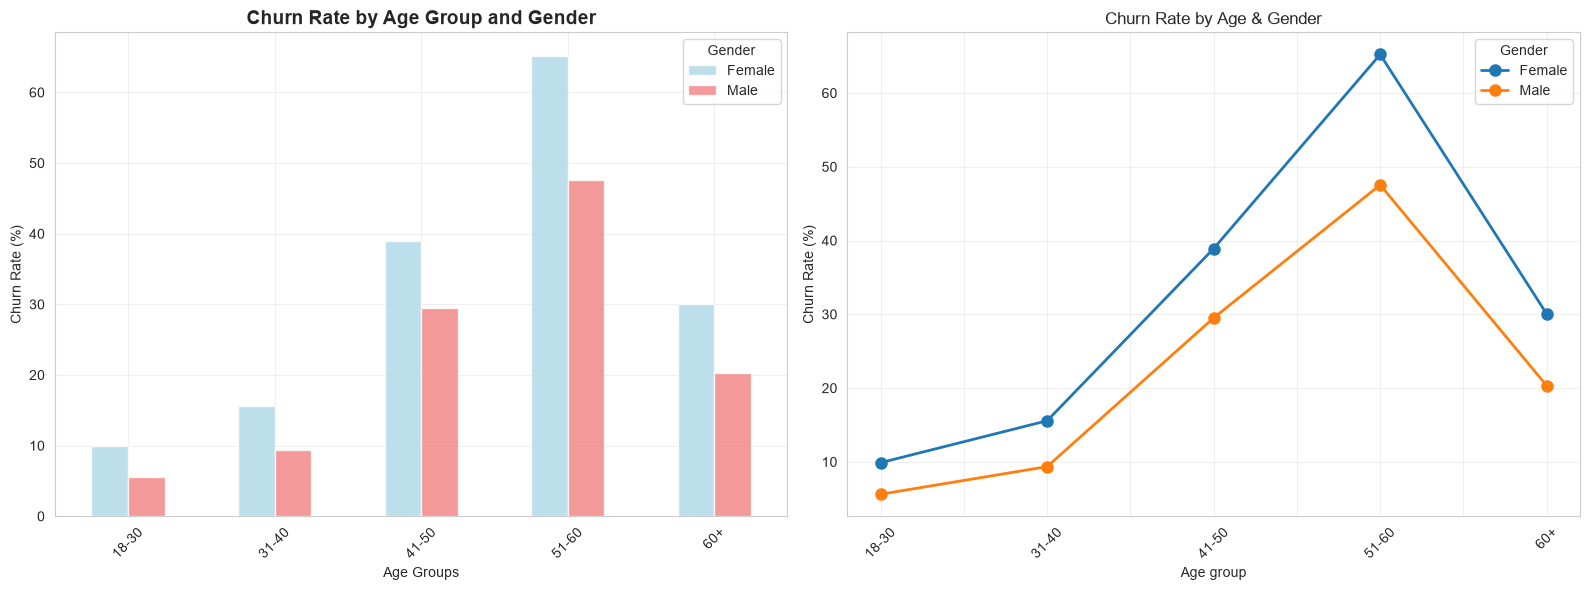


Churn Rate by Age Group and Gender: 
Gender       Female       Male
AgeGroup                      
18-30      9.886364   5.606618
31-40     15.569168   9.349920
41-50     38.909091  29.508197
51-60     65.217391  47.536946
60+       30.046948  20.318725


In [24]:
# Create age groups
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins = [0, 30, 40, 50, 60, 100],
                              labels = ['18-30', '31-40', '41-50', '51-60', '60+'])

# Churn rate by age group and gender
churn_age_gender = df_clean.groupby(['AgeGroup', 'Gender'])['Exited'].mean() * 100
churn_age_gender = churn_age_gender.unstack()

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Grouped bar chart
churn_age_gender.plot(kind = 'bar', ax = axes[0], color = ['lightblue', 'lightcoral'], alpha = 0.8)
axes[0].set_title('Churn Rate by Age Group and Gender', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Age Groups')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend(title = 'Gender')
axes[0].tick_params(axis = 'x', rotation = 45)
axes[0].grid(alpha = 0.3)

# Line Plot
churn_age_gender.plot(kind = 'line', ax = axes[1], marker = 'o', linewidth = 2, markersize = 8)
axes[1].set_title('Churn Rate by Age & Gender')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend(title = 'Gender')
axes[1].tick_params(axis = 'x', rotation = 45)
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

print('\nChurn Rate by Age Group and Gender: ')
print(churn_age_gender)

### Customer Segmentation by Balance and Activity

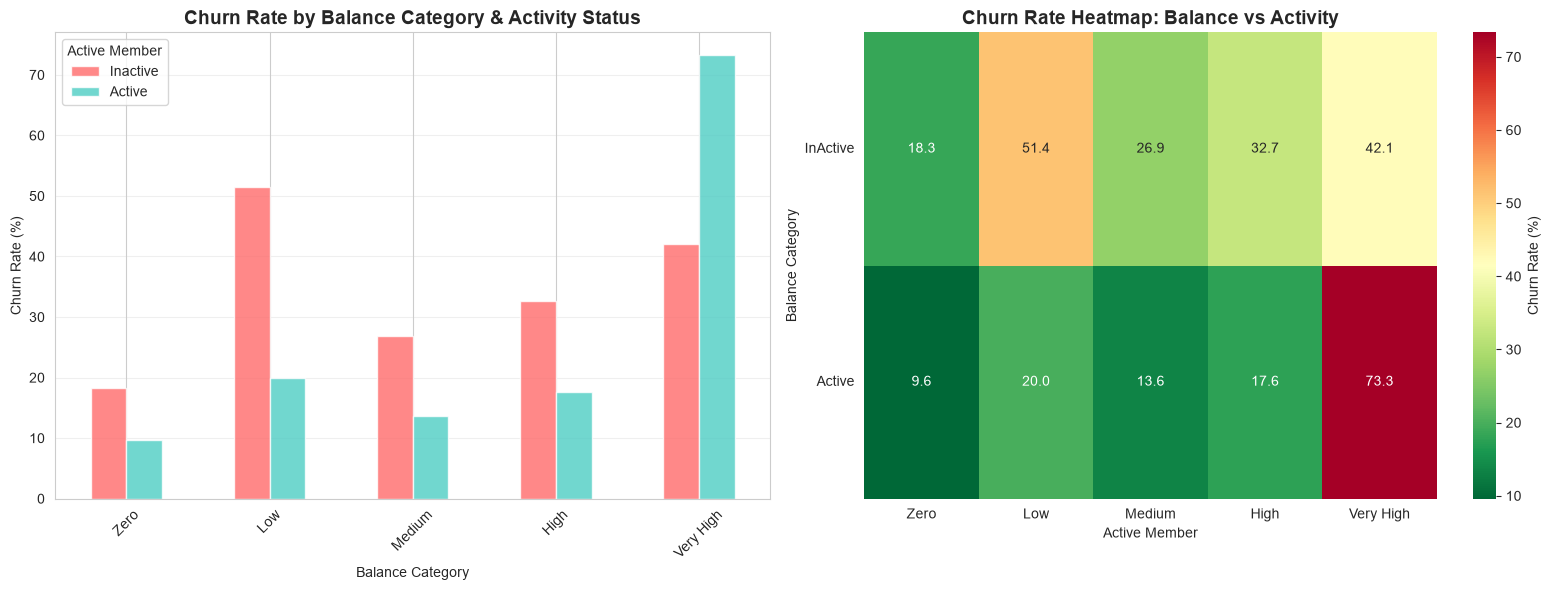


Churn rate by Balance Category and Activity Status: 
IsActiveMember            0          1
Balance_Category                      
Zero              18.348624   9.610251
Low               51.428571  20.000000
Medium            26.890756  13.584906
High              32.691485  17.627677
Very High         42.105263  73.333333


In [25]:
# Create balance categories
df_clean['Balance_Category'] = pd.cut(df_clean['Balance'],
                                      bins = [-1, 0, 50000, 100000, 200000, 300000],
                                      labels = ['Zero', 'Low', 'Medium', 'High', 'Very High'])

# Churn rate by balance category and active member status
churn_balance_active = df_clean.groupby(['Balance_Category', 'IsActiveMember'])['Exited'].mean() * 100
churn_balance_active = churn_balance_active.unstack()

fig, axes = plt.subplots(1, 2, figsize = (16,6))

# Grouped Bar Chart
churn_balance_active.plot(kind = 'bar', ax = axes[0], color = ['#FF6B6B', '#4ECDC4'], alpha = 0.8)
axes[0].set_title('Churn Rate by Balance Category & Activity Status', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Balance Category')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend(['Inactive', 'Active'], title = 'Active Member')
axes[0].tick_params(axis = 'x', rotation = 45)
axes[0].grid(axis = 'y', alpha = 0.3)

# Heatmap
sns.heatmap(churn_balance_active.T, annot = True, fmt = '.1f', cmap = 'RdYlGn_r', ax = axes[1], cbar_kws= {'label': 'Churn Rate (%)'})
axes[1].set_title('Churn Rate Heatmap: Balance vs Activity', fontsize = 14, fontweight = 'bold')
axes[1].set_ylabel('Balance Category')
axes[1].set_xlabel('Active Member')
axes[1].set_yticklabels(['InActive', 'Active'], rotation = 0)

plt.tight_layout()
plt.show()

print("\nChurn rate by Balance Category and Activity Status: ")
print(churn_balance_active)

## Key Insights & Summary

In [26]:
print('=' * 70)
print("Summary Statistics By Churn Statistics")
print('=' * 70)

for feature in numerical_cols:
    print(f'\n{feature}:')
    print(df_clean.groupby('Exited')[feature].describe().round(2))
    print('-' * 70)

Summary Statistics By Churn Statistics

CreditScore:
         count    mean     std    min    25%    50%    75%    max
Exited                                                           
0       7963.0  651.85   95.65  405.0  585.0  653.0  718.0  850.0
1       2037.0  645.35  100.32  350.0  578.0  646.0  716.0  850.0
----------------------------------------------------------------------

Age:
         count   mean    std   min   25%   50%   75%   max
Exited                                                    
0       7963.0  37.41  10.13  18.0  31.0  36.0  41.0  92.0
1       2037.0  44.84   9.76  18.0  38.0  45.0  51.0  84.0
----------------------------------------------------------------------

Tenure:
         count  mean   std  min  25%  50%  75%   max
Exited                                              
0       7963.0  5.03  2.88  0.0  3.0  5.0  7.0  10.0
1       2037.0  4.93  2.94  0.0  2.0  5.0  8.0  10.0
----------------------------------------------------------------------

Balanc

### Key Findings:

**Data Overview:**
- Dataset contains 10,000 customers with 11 features
- Churn Rate: ~20% (imbalanced dataset)
- No missing values or duplicates

**Important Factors Related to Churn:**

1. **Age**: Strong positive corelation to churn.
   - Older customers (45+) have significantly higher churn rates
   - Middle-aged customers (40-60) show the highest churn

2. **Geography**: Germany has the highest churn rate
   - German customers churn more than French and Spanish customers
  
3. **Gender**: Female customers have higher churn rates
   - Across all geographies, females show higher tendency to churn
  
4. **Number of Products**: Critical factor
   - Customers with 3-4 products have extremely high churn rates
   - Customers with 1-2 products are more stable

5. **IsActiveMember**: Strong indicator
   - Inactive members are more likely to churn

6. **Balance**: Moderate positive correlation
   - Customers with higher balances show slightly higher churn tendency
  
**Actionable Insights:**
- Focus retention efforts on: older customers, German market, female customers, inactive members
- Review product bundling strategy (3-4 products correlation with churn)
- Develop targetted retention campaigns based on ustomer segments

## Machine Learning Models

### Data Preparation for Modelling

In [27]:
# Prepare data for modelling - drop the created categories for EDA
df_model = df_clean.drop(columns = ['AgeGroup', 'Balance_Category'], errors= 'ignore')

# Encode Categorical variables
le_geography = LabelEncoder()
le_gender = LabelEncoder()

df_model['Geography'] = le_geography.fit_transform(df_model['Geography'])
df_model['Gender'] = le_gender.fit_transform(df_model['Gender'])

print('Label Encoding:')
print(f'Geography: {dict(zip(le_geography.classes_, le_geography.transform(le_geography.classes_)))}')
print(f'Gender: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}')
print("\nDataset shape:", df_model.shape)
df_model.head()

Label Encoding:
Geography: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Gender: {'Female': np.int64(0), 'Male': np.int64(1)}

Dataset shape: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [28]:
# Split features and target
X = df_model.drop(columns= 'Exited')
y = df_model['Exited']

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

print(f'Training set size: {X_train.shape}')
print(f'Test set size: {X_test.shape}')
print(f'\nTraining set churn distribution:\n{y_train.value_counts(normalize = True)}')
print(f'\nTest set churn distribution:\n{y_test.value_counts(normalize = True)}')

Training set size: (8000, 10)
Test set size: (2000, 10)

Training set churn distribution:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Test set churn distribution:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


In [29]:
# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling completed!')
print(f'Scaled training set shape: {X_train_scaled.shape}')

Feature scaling completed!
Scaled training set shape: (8000, 10)


### Logistic Regression Model

#### Impact of Learning Rate (C parameter)

In [30]:
# Test different C values (inverse of regularization strength)
# Lower C = stronger regularization
# Higher C = weaker regularization

c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
results_c = []

for c in c_values:
    # Train model
    lr_model = LogisticRegression(
        C=c,
        random_state=42,
        max_iter=1000
    )
    lr_model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = lr_model.predict(X_train_scaled)
    y_pred_test = lr_model.predict(X_test_scaled)

    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)

    # Store results for THIS value of C
    results_c.append({
        'C': c,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1 Score': test_f1
    })

# Convert to DataFrame for better visualization
df_results_c = pd.DataFrame(results_c)

print("Impact of C parameter (Regularization Strength):")
print(df_results_c.round(4))

Impact of C parameter (Regularization Strength):
          C  Train Accuracy  Test Accuracy  Precision  Recall  F1 Score
0     0.001          0.7966         0.7980     0.7143  0.0123    0.0242
1     0.010          0.8062         0.8055     0.6184  0.1155    0.1946
2     0.100          0.8076         0.8050     0.5876  0.1400    0.2262
3     1.000          0.8082         0.8050     0.5859  0.1425    0.2292
4    10.000          0.8084         0.8050     0.5859  0.1425    0.2292
5   100.000          0.8084         0.8050     0.5859  0.1425    0.2292
6  1000.000          0.8084         0.8050     0.5859  0.1425    0.2292


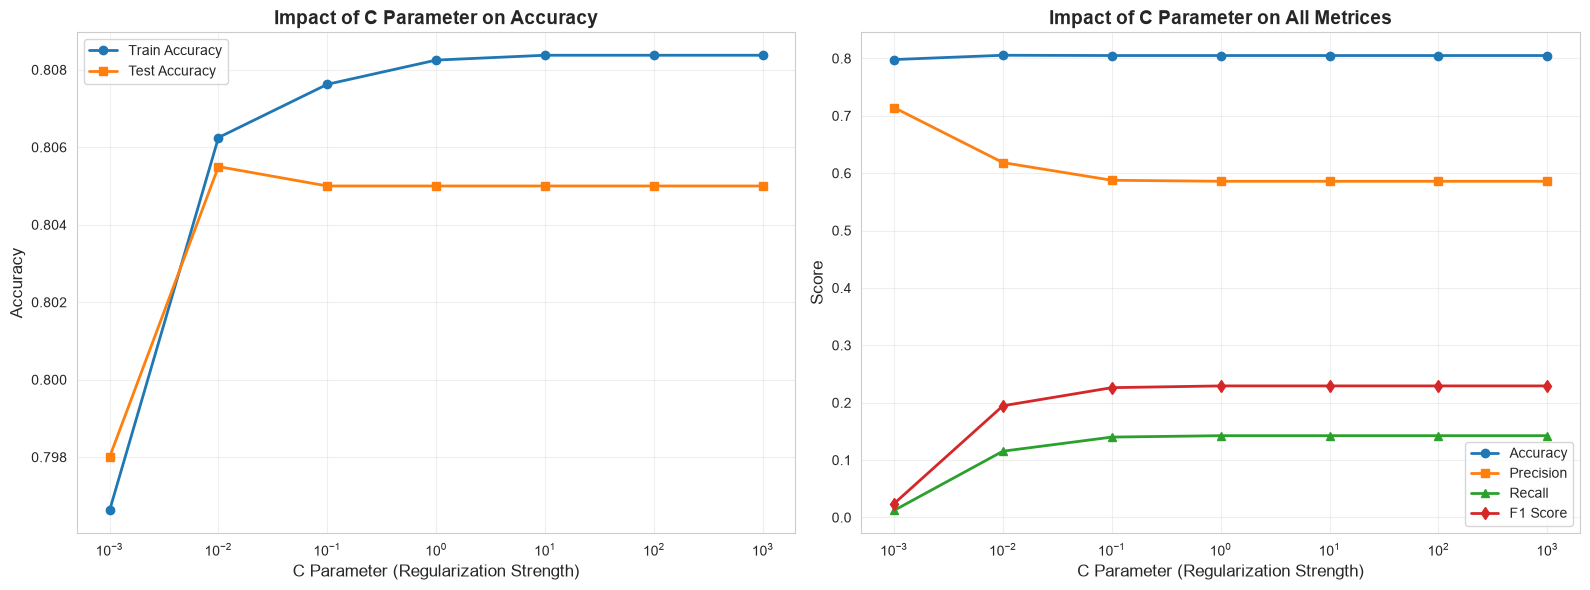

In [31]:
# Visualiza impact of c parameter
fig, axes = plt.subplots(1, 2, figsize = (16,6))

# Plot 1: Accuracy comparison
axes[0].plot(df_results_c['C'], df_results_c['Train Accuracy'], marker = 'o', label = 'Train Accuracy', linewidth = 2)
axes[0].plot(df_results_c['C'], df_results_c['Test Accuracy'], marker = 's', label = 'Test Accuracy', linewidth = 2)
axes[0].set_xscale('log')
axes[0].set_xlabel('C Parameter (Regularization Strength)', fontsize = 12)
axes[0].set_ylabel('Accuracy', fontsize = 12)
axes[0].set_title('Impact of C Parameter on Accuracy', fontsize = 14, fontweight = 'bold')
axes[0].legend()
axes[0].grid(alpha = 0.3)

# Plot 2: All Test Metrics
axes[1].plot(df_results_c['C'], df_results_c['Test Accuracy'], marker = 'o', label = 'Accuracy', linewidth = 2)
axes[1].plot(df_results_c['C'], df_results_c['Precision'], marker = 's', label = 'Precision', linewidth = 2)
axes[1].plot(df_results_c['C'], df_results_c['Recall'], marker = '^', label = 'Recall', linewidth = 2)
axes[1].plot(df_results_c['C'], df_results_c['F1 Score'], marker = 'd', label = 'F1 Score', linewidth = 2)
axes[1].set_xscale('log')
axes[1].set_ylabel('Score', fontsize = 12)
axes[1].set_xlabel('C Parameter (Regularization Strength)', fontsize = 12)
axes[1].set_title('Impact of C Parameter on All Metrices', fontsize = 14, fontweight = 'bold')
axes[1].legend()
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

#### Impact of Threshold Probability

In [32]:
# Train the best model (using optimal C value)
best_c = df_results_c.loc[df_results_c['F1 Score'].idxmax(), 'C']
print(f'Best C value based on F1-Score: {best_c}')

lr_best = LogisticRegression(C = best_c, random_state= 42, max_iter= 1000)
lr_best.fit(X_train_scaled, y_train)

# Get probability predictions
y_prob = lr_best.predict_proba(X_test_scaled)[:, 1]

# Test different threshold values
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
results_threshold = []

for threshold in thresholds:
    #Apply threshold
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold, zero_division= 0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold, zero_division= 0)

    results_threshold.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': recall,
        'F1-Score': f1
    })

df_results_threshold = pd.DataFrame(results_threshold)
print('\nImpact of Threshold Probability: ')
print(df_results_threshold.round(4))

Best C value based on F1-Score: 1.0

Impact of Threshold Probability: 
   Threshold  Accuracy  Precision  Recall  F1-Score
0       0.30    0.7785     0.4589  0.4939    0.4757
1       0.35    0.8000     0.5107  0.4103    0.4550
2       0.40    0.8130     0.5727  0.3194    0.4101
3       0.45    0.8085     0.5769  0.2211    0.3197
4       0.50    0.8050     0.5859  0.1425    0.2292
5       0.55    0.8035     0.6061  0.0983    0.1691
6       0.60    0.8020     0.6222  0.0688    0.1239
7       0.65    0.8010     0.6667  0.0442    0.0829
8       0.70    0.8000     0.7692  0.0246    0.0476


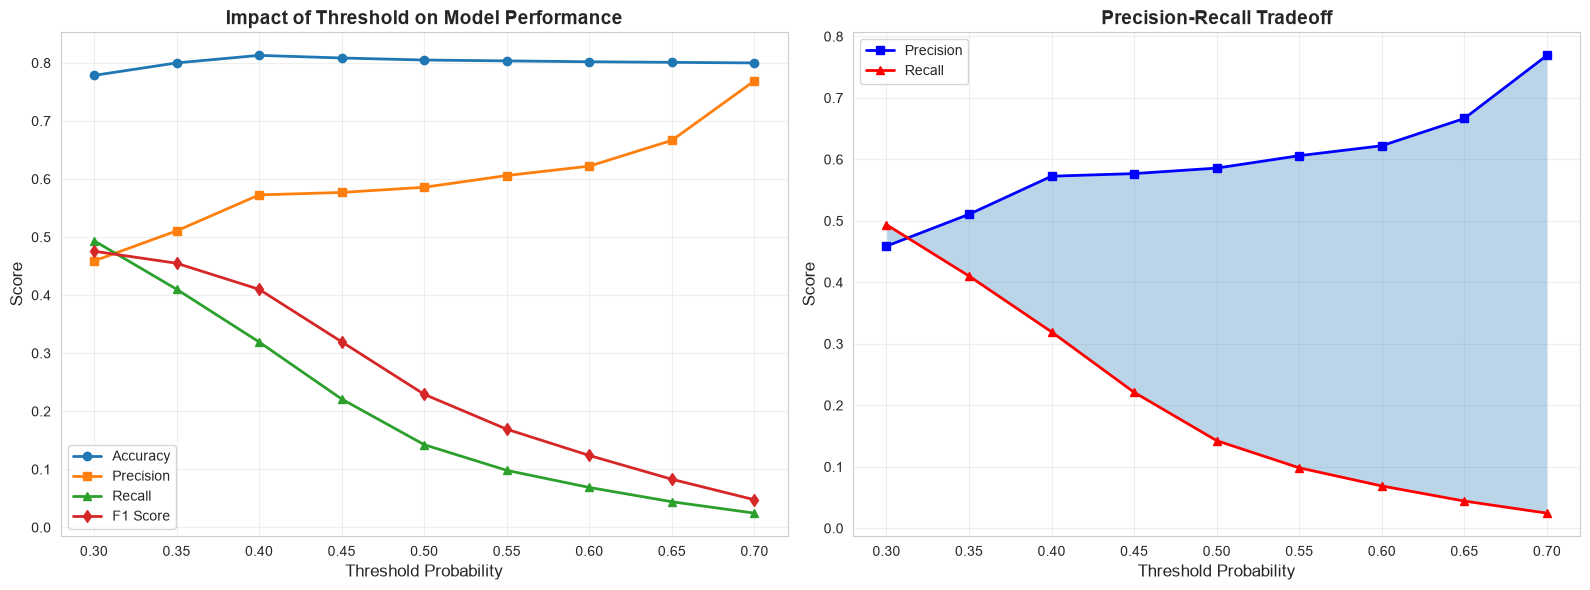

In [33]:
# Visualize Impact of Threshold
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Plot 1: All metrics vs threshold
axes[0].plot(df_results_threshold['Threshold'], df_results_threshold['Accuracy'],
             marker = 'o', label = 'Accuracy', linewidth = 2)
axes[0].plot(df_results_threshold['Threshold'], df_results_threshold['Precision'],
             marker = 's', label = 'Precision', linewidth = 2)
axes[0].plot(df_results_threshold['Threshold'], df_results_threshold['Recall'],
             marker = '^', label = 'Recall', linewidth = 2)
axes[0].plot(df_results_threshold['Threshold'], df_results_threshold['F1-Score'],
             marker = 'd', label = 'F1 Score', linewidth = 2)
axes[0].set_title('Impact of Threshold on Model Performance', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Threshold Probability', fontsize = 12)
axes[0].set_ylabel('Score', fontsize = 12)
axes[0].legend()
axes[0].grid(alpha = 0.3)

# Plot 2: Precision-Recall Tradeoff
axes[1].plot(df_results_threshold['Threshold'], df_results_threshold['Precision'],
             marker = 's', label = 'Precision', linewidth = 2, color = 'blue')
axes[1].plot(df_results_threshold['Threshold'], df_results_threshold['Recall'],
             marker = '^', label = 'Recall', linewidth = 2, color = 'red')
axes[1].fill_between(df_results_threshold['Threshold'],
                     df_results_threshold['Precision'],
                     df_results_threshold['Recall'],
                     alpha = 0.3)
axes[1].set_title('Precision-Recall Tradeoff', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Threshold Probability', fontsize = 12)
axes[1].set_ylabel('Score', fontsize = 12)
axes[1].legend()
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

#### Final Logistic Regression Model Evaluation

In [34]:
# Use default threshold (0.5) for final evaluation
y_pred_lr = lr_best.predict(X_test_scaled)

# Calculate Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 70)
print("Logistic Regression - Final Model Performance")
print("=" * 70)
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_precision:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"ROC AUC: {lr_roc_auc:.4f}")
print("=" * 70)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression - Final Model Performance
Accuracy: 0.8050
Precision: 0.5859
Recall: 0.5859
F1 Score: 0.2292
ROC AUC: 0.7710

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000



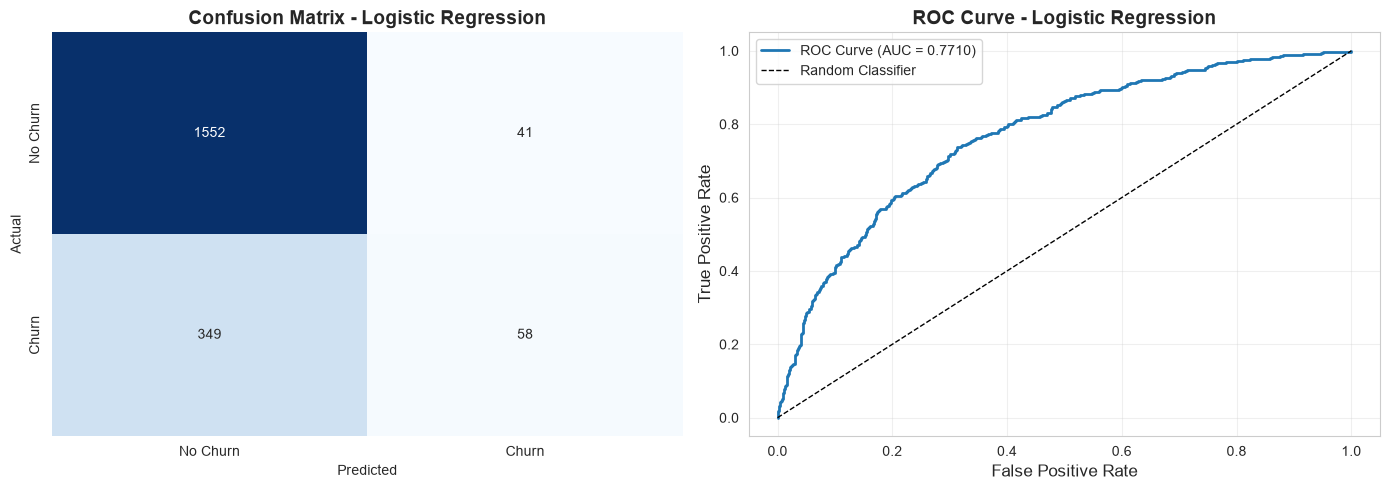

In [35]:
# Confusion Matrix and ROC-Curve
fig, axes = plt.subplots(1, 2, figsize = (14,5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', ax = axes[0], cbar = False)
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, linewidth = 2, label = f'ROC Curve (AUC = {lr_roc_auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth = 1, label = 'Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize = 12)
axes[1].set_ylabel('True Positive Rate', fontsize = 12)
axes[1].set_title('ROC Curve - Logistic Regression', fontsize = 14, fontweight = 'bold')
axes[1].legend()
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

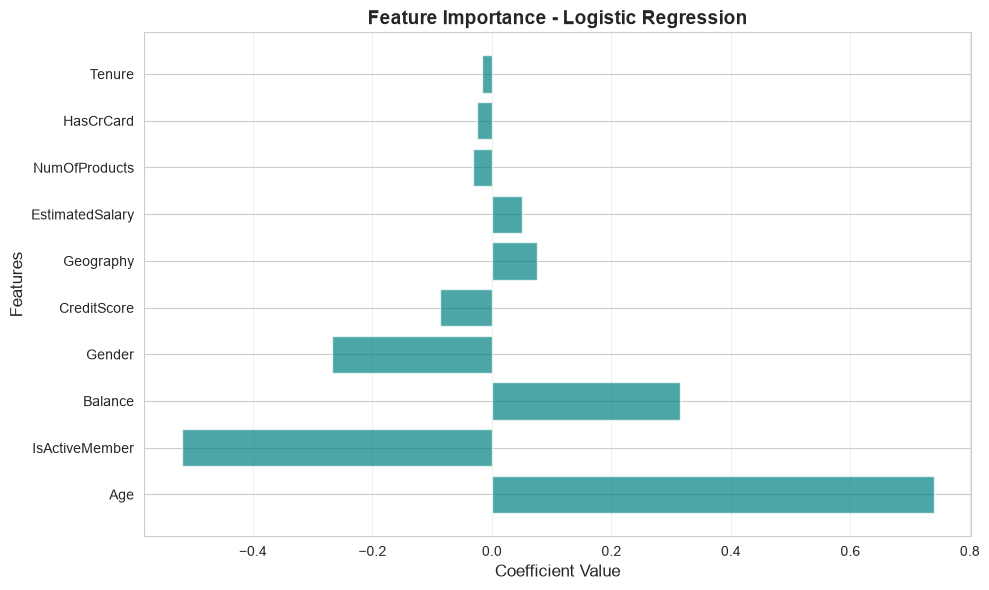


Feature Importance (Coefficients):
           Feature  Coefficient
3              Age     0.739402
8   IsActiveMember    -0.519640
5          Balance     0.314425
2           Gender    -0.267057
0      CreditScore    -0.086363
1        Geography     0.075674
9  EstimatedSalary     0.049505
6    NumOfProducts    -0.031104
7        HasCrCard    -0.025533
4           Tenure    -0.017044


In [36]:
# Feature Importance - Coefficients
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_best.coef_[0]
}).sort_values('Coefficient', key = abs, ascending= False)

plt.figure(figsize = (10,6))
plt.barh(feature_importance_lr['Feature'], feature_importance_lr['Coefficient'], color = 'teal', alpha = 0.7)
plt.xlabel('Coefficient Value', fontsize = 12)
plt.ylabel('Features', fontsize = 12)
plt.title('Feature Importance - Logistic Regression', fontsize = 14, fontweight = 'bold')
plt.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.show()

print("\nFeature Importance (Coefficients):")
print(feature_importance_lr)

### Decision Tree Model

#### Decision Tree without Hyperparameter Tuning

In [37]:
# Train Decision Tree with default parameters (no tuning)
dt_default = DecisionTreeClassifier(random_state= 42)
dt_default.fit(X_train, y_train)

# Predictions
y_pred_dt_default = dt_default.predict(X_test)
y_pred_dt_default_train = dt_default.predict(X_train)

# Evaluate
dt_default_train_acc = accuracy_score(y_train, y_pred_dt_default_train)
dt_default_test_acc = accuracy_score(y_test, y_pred_dt_default)
dt_default_precision = precision_score(y_test, y_pred_dt_default)
dt_default_recall = recall_score(y_test, y_pred_dt_default)
dt_default_f1 = f1_score(y_test, y_pred_dt_default)
dt_default_roc_auc = roc_auc_score(y_test, y_pred_dt_default)

print("=" * 70)
print("Decision Tree (Default - No Tuning)")
print("-" * 70)
print(f"Train Accuracy: {dt_default_train_acc:.4f}")
print(f"Test Accuracy: {dt_default_test_acc:.4f}")
print(f"Precision: {dt_default_precision:.4f}")
print(f"Recall: {dt_default_recall:.4f}")
print(f"F1 Score: {dt_default_f1:.4f}")
print(f"ROC AUC: {dt_default_f1:.4f}")
print("=" * 70)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt_default))

Decision Tree (Default - No Tuning)
----------------------------------------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 0.7765
Precision: 0.4533
Recall: 0.4767
F1 Score: 0.4647
ROC AUC: 0.4647

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1593
           1       0.45      0.48      0.46       407

    accuracy                           0.78      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.78      0.78      0.78      2000



#### Decision Tree with Hyperparameter Tuning (Grid search CV)

In [38]:
# Define parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize Decision Tree
dt_tuned = DecisionTreeClassifier(random_state= 42)

# Grid Search with Cross-Validation
print("Performing Grid Searchg with 5-Fold Cross-Validation....")
print("This may take a few moments......\n")

grid_search = GridSearchCV(
    estimator= dt_tuned,
    param_grid= param_grid,
    cv = 5,
    scoring= 'f1',
    n_jobs= 1,
    verbose= 1
)

grid_search.fit(X_train, y_train)

print("\n" + "=" * 70)
print("Grid Search Results")
print("=" * 70)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")
print("=" * 70)

Performing Grid Searchg with 5-Fold Cross-Validation....
This may take a few moments......

Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Grid Search Results
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV F1 Score: 0.5578


In [39]:
# Get the best model
dt_best = grid_search.best_estimator_

# Predictions with tuned model
y_pred_dt_tuned = dt_best.predict(X_test)
y_pred_dt_tuned_train = dt_best.predict(X_train)

# Evaluate trained model
dt_tuned_train_accuracy = accuracy_score(y_train, y_pred_dt_tuned_train)
dt_tuned_test_accuracy = accuracy_score(y_test, y_pred_dt_tuned)
dt_tuned_precision = precision_score(y_test, y_pred_dt_tuned)
dt_tuned_recall = recall_score(y_test, y_pred_dt_tuned)
dt_tuned_f1 = f1_score(y_test, y_pred_dt_tuned)
dt_tuned_roc_auc = roc_auc_score(y_test, dt_best.predict_proba(X_test)[:, 1])

print("=" * 70)
print("Decision Tree (Tuned with Grid Search CV)")
print("=" * 70)
print(f"Train Accuracy: {dt_tuned_train_accuracy:.4f}")
print(f"Test Accuracy: {dt_tuned_test_accuracy:.4f}")
print(f"Precision: {dt_tuned_precision:.4f}")
print(f"Recall: {dt_tuned_recall:.4f}")
print(f"F1-Score: {dt_tuned_f1:.4f}")
print(f"ROC AUC: {dt_tuned_roc_auc:.4f}")
print("=" * 70)
print("\nClassification Report")
print(classification_report(y_test, y_pred_dt_tuned))

Decision Tree (Tuned with Grid Search CV)
Train Accuracy: 0.8965
Test Accuracy: 0.8345
Precision: 0.6145
Recall: 0.5012
F1-Score: 0.5521
ROC AUC: 0.7796

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1593
           1       0.61      0.50      0.55       407

    accuracy                           0.83      2000
   macro avg       0.75      0.71      0.73      2000
weighted avg       0.82      0.83      0.83      2000



#### Cross-Validation Analysis

In [40]:
# Perform cross validation on both models
print("Performing 10-Fold Cross Validation...\n")

# CV for default model
cv_scores_default = cross_val_score(dt_default, X_train, y_train, cv = 10, scoring= 'accuracy')
cv_f1_default = cross_val_score(dt_default, X_train, y_train, cv = 10, scoring= 'f1')

# CV for tuned model
cv_scores_tuned = cross_val_score(dt_best, X_train, y_train, cv = 10, scoring= 'accuracy')
cv_f1_tuned = cross_val_score(dt_best, X_train, y_train, cv = 10, scoring= 'f1')

print("=" * 70)
print("Cross Validation Results (10-Fold)")
print("=" * 70)
print("\nDefault Decision Tree: ")
print(f" Accuracy: {cv_scores_default.mean():.4f} (+/- {cv_scores_default.std():.4f})")
print(f" F1 Score: {cv_f1_default.mean():.4f} (+/- {cv_f1_default.std():.4f})")
print("\nTuned Decision Tree:")
print(f" Accuracy: {cv_scores_tuned.mean():.4f} (+/- {cv_scores_tuned.std():.4f})")
print(f" F1 score: {cv_f1_tuned.mean():.4f} (+/- {cv_f1_tuned.std():.4f})")
print("=" * 70)

Performing 10-Fold Cross Validation...

Cross Validation Results (10-Fold)

Default Decision Tree: 
 Accuracy: 0.7873 (+/- 0.0082)
 F1 Score: 0.4845 (+/- 0.0241)

Tuned Decision Tree:
 Accuracy: 0.8316 (+/- 0.0117)
 F1 score: 0.5442 (+/- 0.0261)


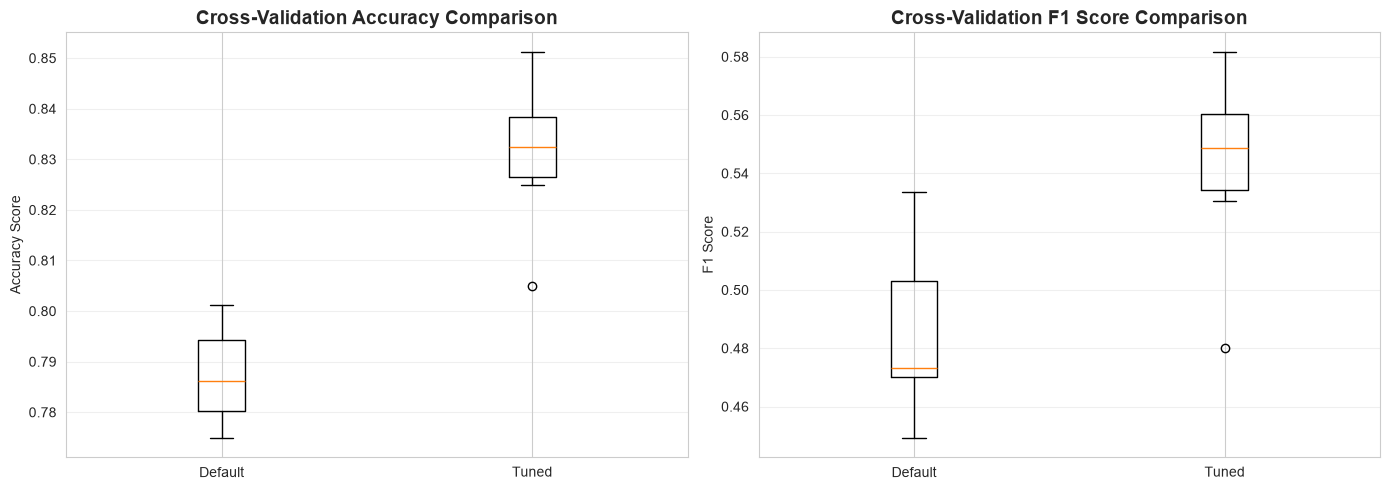

In [41]:
# Visualize CV Results
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Box Plot for accuracy
axes[0].boxplot([cv_scores_default, cv_scores_tuned], tick_labels = ['Default', 'Tuned'])
axes[0].set_title('Cross-Validation Accuracy Comparison', fontsize = 14, fontweight = 'bold')
axes[0].set_ylabel('Accuracy Score')
axes[0].grid(axis = 'y', alpha = 0.3)

# Box Plot for F1 score
axes[1].boxplot([cv_f1_default, cv_f1_tuned], tick_labels = ['Default', 'Tuned'])
axes[1].set_title('Cross-Validation F1 Score Comparison', fontsize = 14, fontweight = 'bold')
axes[1].set_ylabel('F1 Score')
axes[1].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

#### Decision Tree Comparison and Visualization

Decison Tree Models Comparison
           Metric  Default DT  Tuned DT
0  Train Accuracy      1.0000    0.8965
1   Test Accuracy      0.7765    0.8345
2       Precision      0.4533    0.4533
3          Recall      0.4767    0.4767
4        F1 Score      0.4647    0.5521
5         ROC AUC      0.6649    0.7796


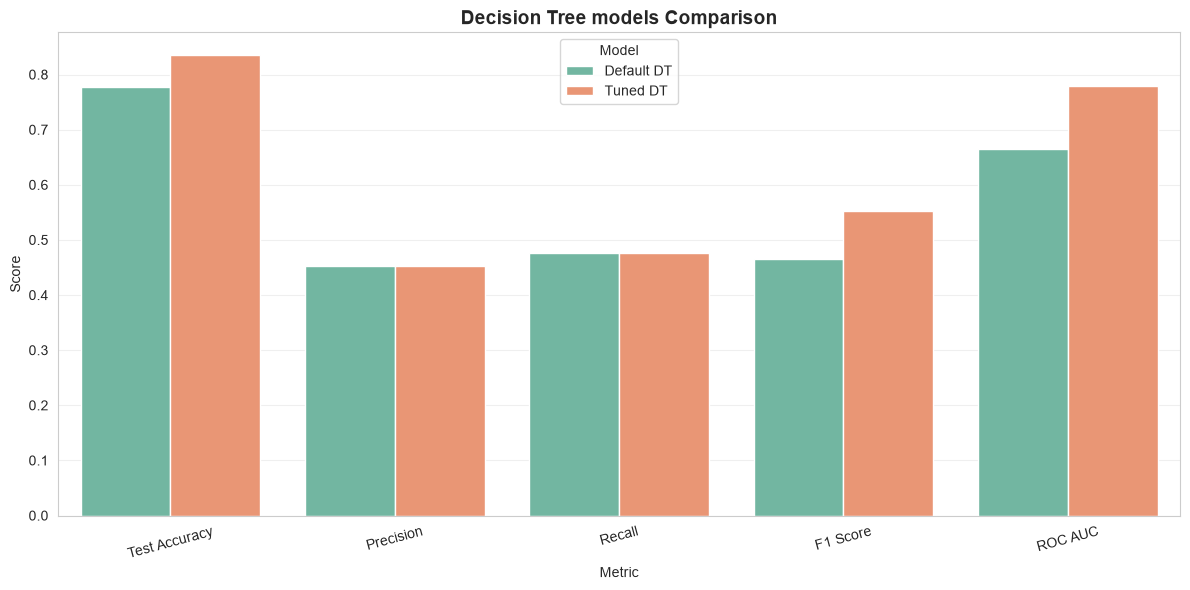

In [42]:
# Compare both Decision Tree models
comparison_df = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Default DT': [dt_default_train_acc, dt_default_test_acc, dt_default_precision, dt_default_recall, dt_default_f1, dt_default_roc_auc],
    'Tuned DT': [dt_tuned_train_accuracy, dt_tuned_test_accuracy, dt_default_precision, dt_default_recall, dt_tuned_f1, dt_tuned_roc_auc]
})

print('=' * 70)
print('Decison Tree Models Comparison')
print('=' * 70)
print(comparison_df.round(4))
print('=' * 70)

# Visualize comparison
comparison_melted = comparison_df.melt(id_vars = 'Metric', var_name = 'Model', value_name = 'Score')
comparison_melted = comparison_melted[comparison_melted['Metric'] != 'Train Accuracy'] # Exclude for clarity

plt.figure(figsize = (12, 6))
sns.barplot(data = comparison_melted, x = 'Metric', y = 'Score', hue = 'Model', palette = 'Set2')
plt.title('Decision Tree models Comparison', fontsize = 14, fontweight = 'bold')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.xticks(rotation = 15)
plt.legend(title = 'Model')
plt.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()
plt.show()

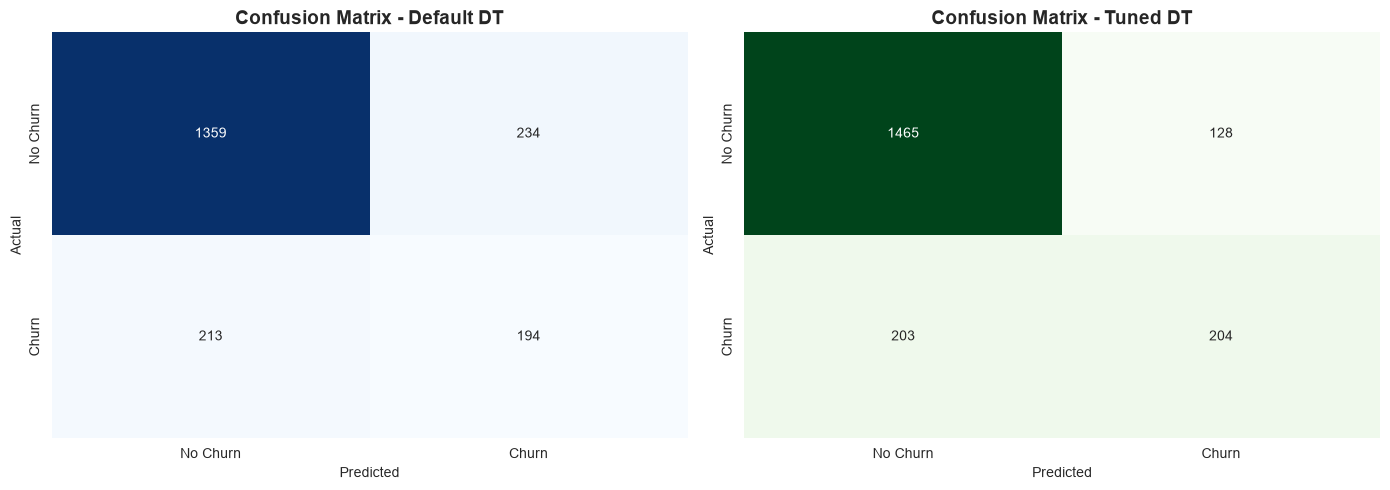

In [43]:
# Confusion Metrics side by side
fig, axes = plt.subplots(1, 2, figsize = (14,5))

# Default DT Confusion Matrix
cm_default = confusion_matrix(y_test, y_pred_dt_default)
sns.heatmap(cm_default, annot = True, fmt = 'd', cmap = 'Blues', ax = axes[0], cbar = False)
axes[0].set_title('Confusion Matrix - Default DT', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# Tuned DT Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_dt_tuned)
sns.heatmap(cm_tuned, annot = True, fmt = 'd', cmap = 'Greens', ax = axes[1], cbar = False)
axes[1].set_title('Confusion Matrix - Tuned DT', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

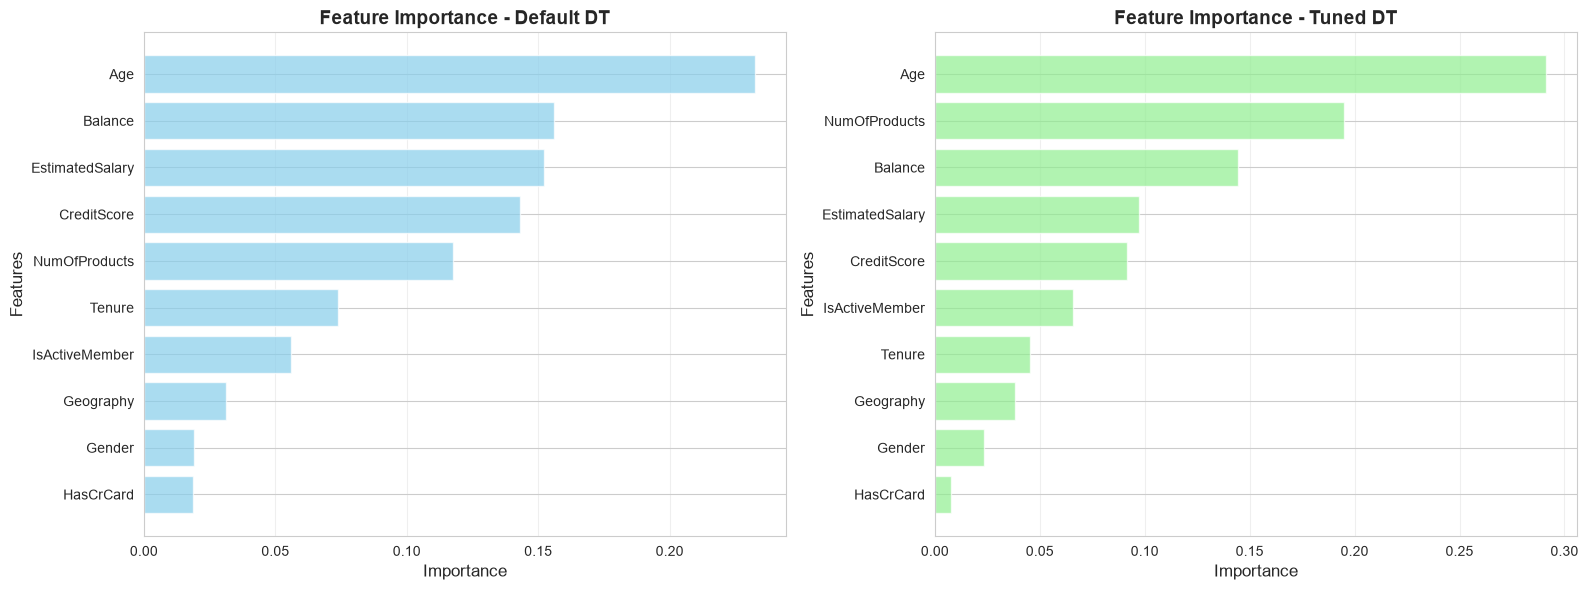


Feature Importance - Default DT:
           Feature  Importance
3              Age    0.232606
5          Balance    0.156012
9  EstimatedSalary    0.152172
0      CreditScore    0.143229
6    NumOfProducts    0.117425
4           Tenure    0.073685
8   IsActiveMember    0.055785
1        Geography    0.031314
2           Gender    0.019106
7        HasCrCard    0.018665

Feature Importance - Tuned DT:
           Feature  Importance
3              Age    0.291372
6    NumOfProducts    0.195049
5          Balance    0.144492
9  EstimatedSalary    0.097476
0      CreditScore    0.091613
8   IsActiveMember    0.065734
4           Tenure    0.045354
1        Geography    0.038079
2           Gender    0.023167
7        HasCrCard    0.007665


In [44]:
# Feature Importance for both models
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Default DT feature importance
feat_imp_default = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_default.feature_importances_
}).sort_values('Importance', ascending= False)

axes[0].barh(feat_imp_default['Feature'], feat_imp_default['Importance'], color = 'skyblue', alpha = 0.7)
axes[0].set_xlabel('Importance', fontsize = 12)
axes[0].set_ylabel('Features', fontsize = 12)
axes[0].set_title('Feature Importance - Default DT', fontsize = 14, fontweight = 'bold')
axes[0].invert_yaxis()
axes[0].grid(axis = 'x', alpha = 0.3)

# Tuned DT Feature Importance
feat_imp_tuned = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_best.feature_importances_
}).sort_values('Importance', ascending = False)

axes[1].barh(feat_imp_tuned['Feature'], feat_imp_tuned['Importance'], color = 'lightgreen', alpha = 0.7)
axes[1].set_xlabel('Importance', fontsize = 12)
axes[1].set_ylabel('Features', fontsize = 12)
axes[1].set_title('Feature Importance - Tuned DT', fontsize = 14, fontweight = 'bold')
axes[1].invert_yaxis()
axes[1].grid(axis = 'x', alpha = 0.3)

plt.tight_layout()
plt.show()

print('\nFeature Importance - Default DT:')
print(feat_imp_default)
print('\nFeature Importance - Tuned DT:')
print(feat_imp_tuned)

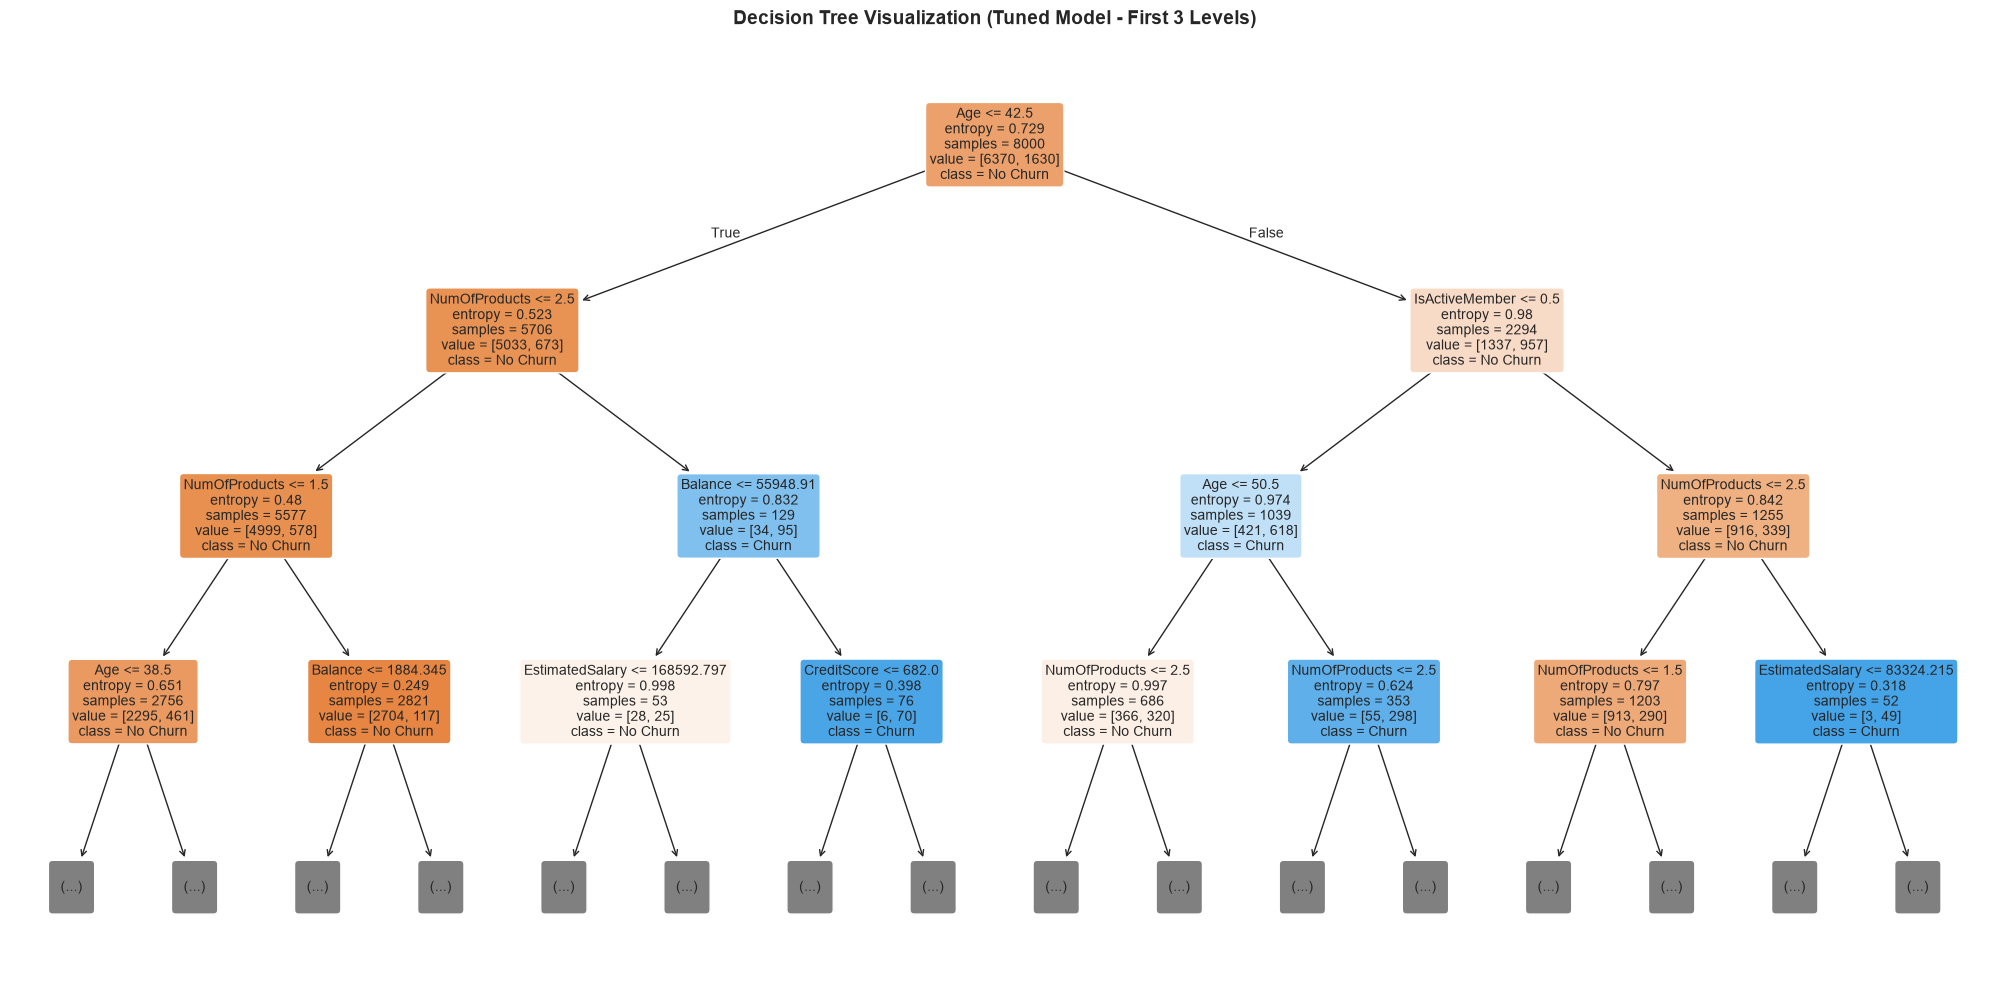


Tree Depth: 19
Number of Leaves: 414


In [45]:
# visualise the Tuned Decision Tree (first few levels for clarity)
plt.figure(figsize = (20, 10))
tree.plot_tree(dt_best,
               feature_names= X.columns,
               class_names= ['No Churn', 'Churn'],
               filled = True,
               rounded = True,
               max_depth= 3, # Show only first 3 levels for readability
               fontsize = 10)
plt.title('Decision Tree Visualization (Tuned Model - First 3 Levels)', fontsize = 14, fontweight = 'bold', pad = 20)
plt.tight_layout()
plt.show()

print(f'\nTree Depth: {dt_best.get_depth()}')
print(f'Number of Leaves: {dt_best.get_n_leaves()}')

### Overall model Comparison

All Models Comparison
                     Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0      Logistic Regression    0.8050     0.5859  0.1425    0.2292   0.7710
1  Decision Tree (Default)    0.7765     0.4533  0.4767    0.4647   0.6649
2    Decision Tree (Tuned)    0.8345     0.6145  0.5012    0.5521   0.7796


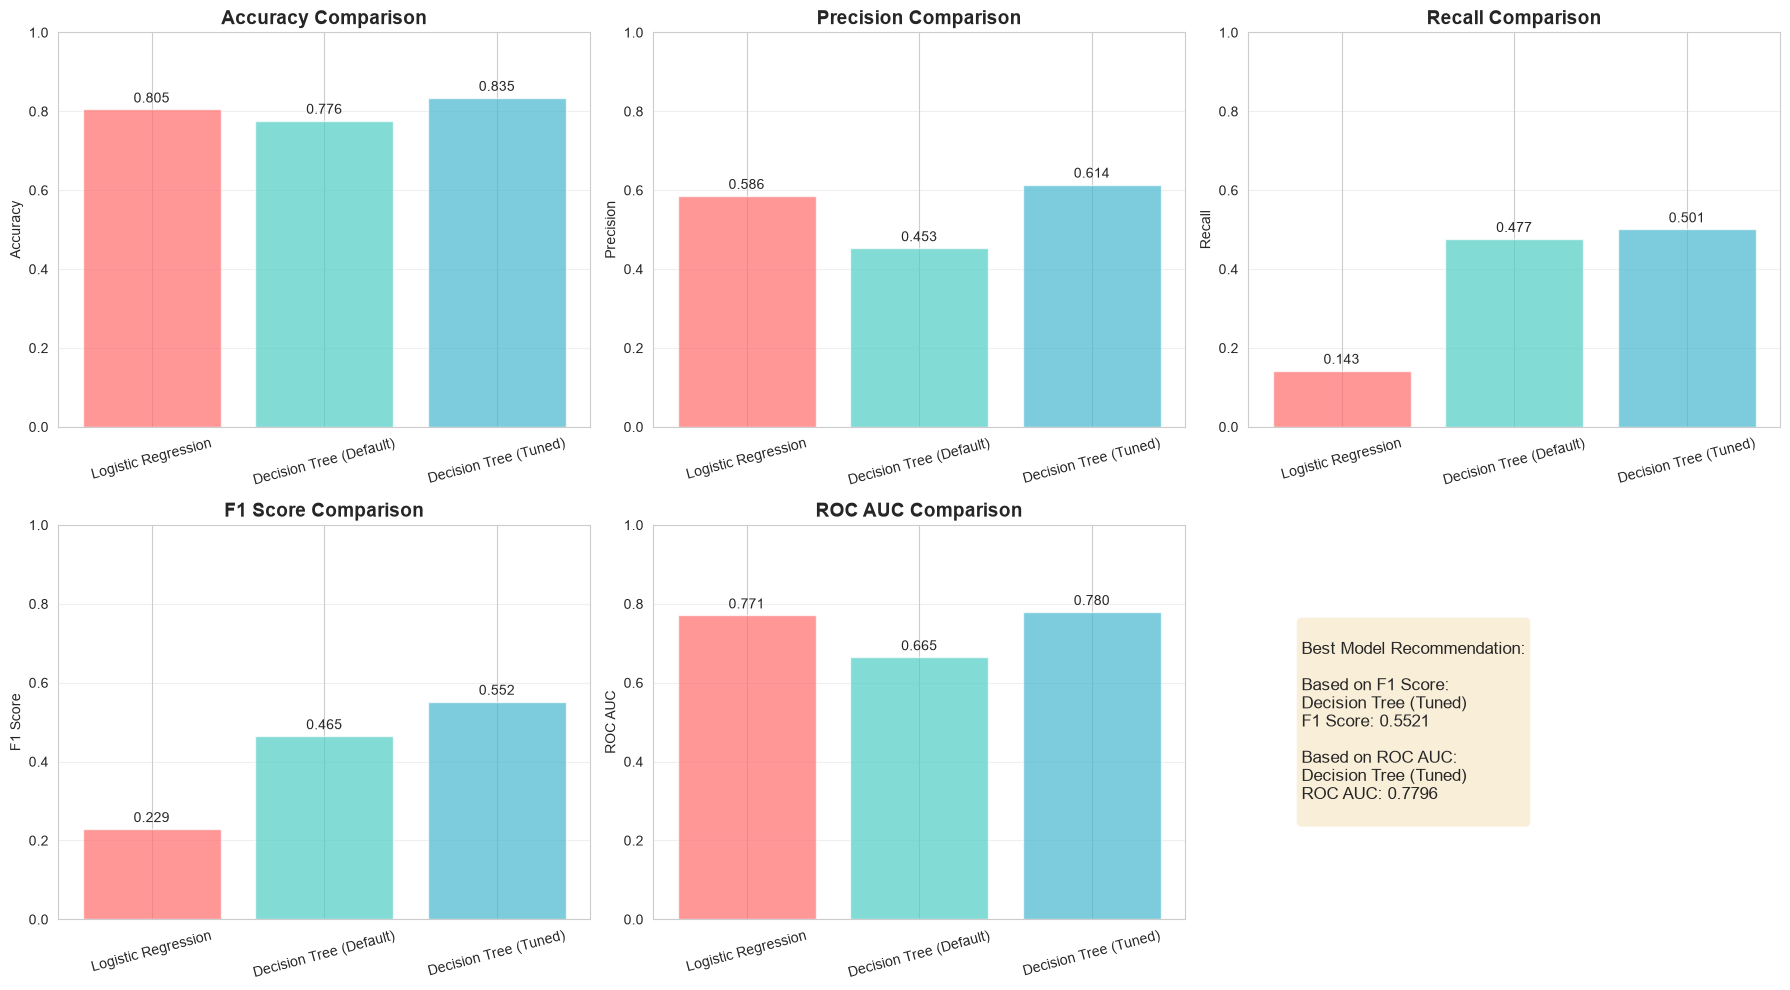

In [46]:
# Compare all models
all_models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (Default)', 'Decision Tree (Tuned)'],
    'Accuracy': [lr_accuracy, dt_default_test_acc, dt_tuned_test_accuracy],
    'Precision': [lr_precision, dt_default_precision, dt_tuned_precision],
    'Recall': [lr_recall, dt_default_recall, dt_tuned_recall],
    'F1 Score': [lr_f1, dt_default_f1, dt_tuned_f1],
    'ROC AUC': [lr_roc_auc, dt_default_roc_auc, dt_tuned_roc_auc]
})

print('=' * 70)
print('All Models Comparison')
print('=' * 70)
print(all_models_comparison.round(4))
print('=' * 70)

# Visualize comparison
all_models_melted = all_models_comparison.melt(id_vars= 'Model', var_name= 'Metric', value_name= 'Score')

fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics):
    data = all_models_comparison[['Model',metric]]
    axes[idx].bar(data['Model'], data[metric], color = colors, alpha = 0.7)
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis = 'x', rotation = 15)
    axes[idx].set_title(f'{metric} Comparison', fontsize = 14, fontweight = 'bold')
    axes[idx].grid(axis = 'y', alpha = 0.3)
    axes[idx].set_ylim([0,1])

    # Add value labels on bars
    for i, v in enumerate(data[metric]):
        axes[idx].text(i,v + 0.01, f'{v:.3f}', ha = 'center', va = 'bottom', fontsize = 10)

# Overall Comparison
axes[5].axis('off')
summary_text = f"""
Best Model Recommendation:

Based on F1 Score:
{all_models_comparison.loc[all_models_comparison['F1 Score'].idxmax(), 'Model']}
F1 Score: {all_models_comparison['F1 Score'].max():.4f}

Based on ROC AUC:
{all_models_comparison.loc[all_models_comparison['ROC AUC'].idxmax(), 'Model']}
ROC AUC: {all_models_comparison['ROC AUC'].max():.4f}
"""

axes[5].text(0.1, 0.5, summary_text, fontsize = 12, verticalalignment = 'center',
             bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.tight_layout()
plt.show()

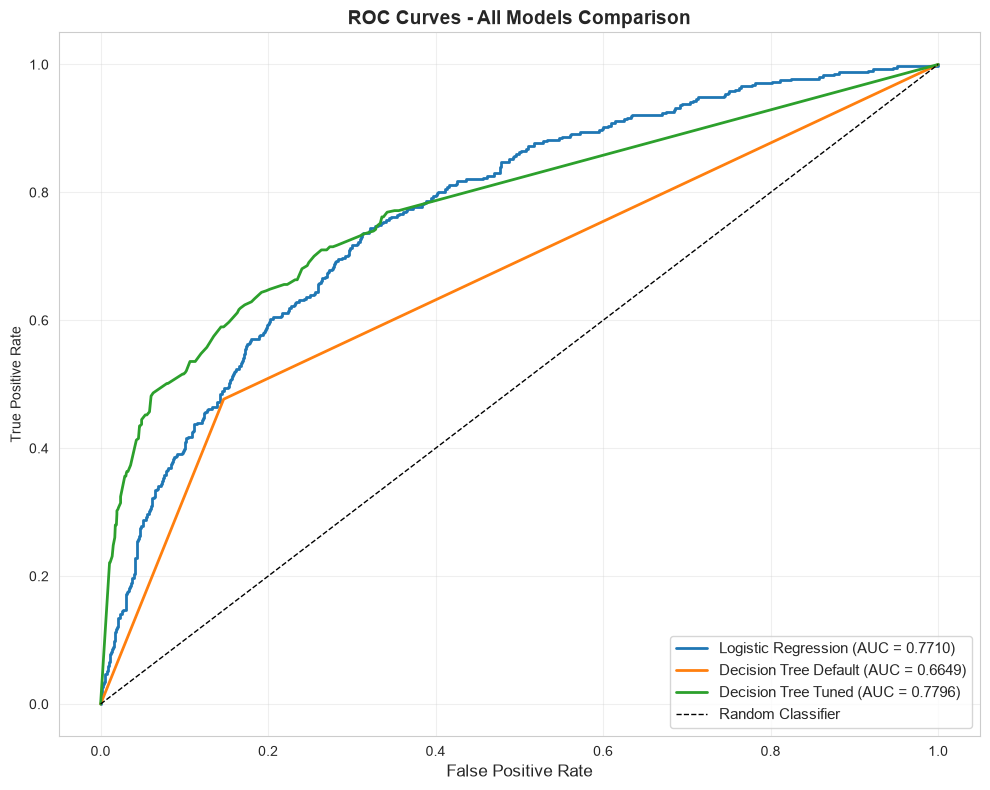

In [47]:
# ROC Curves Comparison
plt.figure(figsize = (10,8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr_lr, tpr_lr, linewidth = 2, label = f'Logistic Regression (AUC = {lr_roc_auc:.4f})')

# Default DT
fpr_dt_default, tpr_dt_default, _ = roc_curve(y_test, dt_default.predict_proba(X_test)[:, 1])
plt.plot(fpr_dt_default, tpr_dt_default, linewidth = 2, label = f'Decision Tree Default (AUC = {dt_default_roc_auc:.4f})')

# Tuned DT
fpr_dt_tuned, tpr_dt_tuned, _ = roc_curve(y_test, dt_best.predict_proba(X_test)[:, 1])
plt.plot(fpr_dt_tuned, tpr_dt_tuned, linewidth = 2, label = f'Decision Tree Tuned (AUC = {dt_tuned_roc_auc:.4f})')

# Random Classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth = 1, label = 'Random Classifier')

plt.xlabel('False Positive Rate', fontsize = 12)
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models Comparison', fontsize = 14, fontweight = 'bold')
plt.legend(loc = 'lower right', fontsize = 11)
plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### Key Machine Learning Insights

**Logistic Regression:**
- **C Paramerter Impact**: Higher C-values (weaker regularization) generally improved performance up to a point, showing the importance of model complexity tuning
- **Threshold Impact**: Adjusting probability thresholds allows fine-tuning the precision-recall tradeoff based on business needs
- **Performance**: Good baseline performance with interpretable coefficients
- **Best Features**: Age, Geography and IsActiveMember showed strongest predictive power

**Decision Trees:**
- **Without Tuning**: The default models showed signs of overfitting (high train accuracy, lower test accuracy)
- **With Hyperparameter Tuning**: Grid Search CV significantly improved generalization
- **Cross-Validation**: Tuned model showed more consistent performance across folds with lower variance
- **Feature Importance**: Age and balance were the most important splitting features

**Overall Findings:**
- Hyperparameter Tuning and Cross-Validation are crucial for optimal model performance
- The tuned Decision Tree slightly outperformed Logistic Regression in most metrics
- Feature Engineering and proper pre-processing significantly impact model quality
- Both models identified similar key features (Age, Balance Geography) as most predictive

## Random Forest Model

### Random Forest without Hyperparameter tuning

In [48]:
# Train Random Forest with default parameters
rf_default = RandomForestClassifier(random_state= 42, n_jobs= -1)
rf_default.fit(X_train, y_train)

# Predictions
y_pred_rf_default = rf_default.predict(X_test)
y_pred_rf_default_train = rf_default.predict(X_train)
y_prob_rf_default = rf_default.predict_proba(X_test)[:,1]

# Evaluate
rf_default_train_acc = accuracy_score(y_train, y_pred_rf_default_train)
rf_default_test_acc = accuracy_score(y_test, y_pred_rf_default)
rf_default_precision = precision_score(y_test, y_pred_rf_default)
rf_default_recall = recall_score(y_test, y_pred_rf_default)
rf_default_f1 = f1_score(y_test, y_pred_rf_default)
rf_default_roc_auc = roc_auc_score(y_test, y_prob_rf_default)

print("=" * 70)
print("Random Forest (Default - No Tuning)")
print("=" * 70)
print(f"Train Accuracy: {rf_default_train_acc:.4f}")
print(f"Test Accuracy: {rf_default_test_acc:.4f}")
print(f"Precision: {rf_default_precision:.4f}")
print(f"Recall: {rf_default_recall:.4f}")
print(f"F1 Score: {rf_default_f1:.4f}")
print(f"ROC AUC: {rf_default_roc_auc:.4f}")
print("=" * 70)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_default))

Random Forest (Default - No Tuning)
Train Accuracy: 1.0000
Test Accuracy: 0.8650
Precision: 0.7819
Recall: 0.4668
F1 Score: 0.5846
ROC AUC: 0.8467

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



### Random Forest with Hyperparameter Tuning (Grid Search CV)

In [49]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize Random Forest
rf_tuned = RandomForestClassifier(random_state= 42, n_jobs= 1)

# Grid Search with Cross-Validation
print('Performing Grid Search with 5-Fold Cross-Validation for Random Forest...')
print('This may take several minutes....\n')

grid_search_rf = GridSearchCV(
    estimator= rf_tuned,
    param_grid= param_grid_rf,
    cv = 5,
    scoring= 'f1',
    n_jobs= 1,
    verbose= 1
)

grid_search_rf.fit(X_train, y_train)

print("\n" + "=" * 70)
print("Random Forest - Grid Search Results")
print("=" * 70)
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best CV F1 Score: {grid_search_rf.best_score_:.4f}")
print("=" * 70)

Performing Grid Search with 5-Fold Cross-Validation for Random Forest...
This may take several minutes....

Fitting 5 folds for each of 540 candidates, totalling 2700 fits

Random Forest - Grid Search Results
Best Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1 Score: 0.5809


In [50]:
# Get the best Random Forest Model
rf_best = grid_search_rf.best_estimator_

# Predictions with Tuned Model
y_pred_rf_tuned = rf_best.predict(X_test)
y_pred_rf_tuned_train = rf_best.predict(X_train)
y_prob_rf_tuned = rf_best.predict_proba(X_test)[:,1]

# Evaluate tuned model
rf_tuned_train_accuracy = accuracy_score(y_train, y_pred_rf_tuned_train)
rf_tuned_test_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned)
rf_tuned_recall = recall_score(y_test, y_pred_rf_tuned)
rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned)
rf_tuned_roc_auc = roc_auc_score(y_test, y_prob_rf_tuned)

print("=" * 70)
print("Random Forest (Tuned with GRID Search CV)")
print("=" * 70)
print(f"Train Accuracy: {rf_tuned_train_accuracy:.4f}")
print(f"Test Accuracy: {rf_tuned_test_accuracy:.4f}")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall: {rf_tuned_recall:.4f}")
print(f"F1 Score: {rf_tuned_f1:.4f}")
print(f"ROC AUC: {rf_tuned_roc_auc:.4f}")
print("=" * 70)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

Random Forest (Tuned with GRID Search CV)
Train Accuracy: 0.9489
Test Accuracy: 0.8580
Precision: 0.7639
Recall: 0.4373
F1 Score: 0.5563
ROC AUC: 0.8505

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.76      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



### Cross-Validation Analysis

In [51]:
# Perform Cross-Validation on both Random Forest models
print("Performing 10-Fold Cross-Validation for Random Forest...\n")

# CV for default model
cv_scores_rf_default = cross_val_score(rf_default, X_train, y_train, cv = 10, scoring = 'accuracy')
cv_f1_rf_default = cross_val_score(rf_default, X_train, y_train, cv = 10, scoring = 'f1')

# CV for tuned model
cv_scores_rf_tuned = cross_val_score(rf_best, X_train, y_train, cv = 10, scoring= 'accuracy')
cv_f1_rf_tuned = cross_val_score(rf_best, X_train, y_train, cv = 10, scoring = 'f1')

print("=" * 70)
print("\nRandom Forest - Cross-Validation Results (10-Fold)")
print("=" * 70)
print('\nDefault Random Forest:')
print(f'  Accuracy: {cv_scores_rf_default.mean():.4f} (+/- {cv_scores_rf_default.std():.4f})')
print(f'  F1 Score: {cv_f1_default.mean():.4f} (+/- {cv_f1_rf_default.std():.4f})')
print('\nTuned Random Forest:')
print(f'  Accuracy {cv_scores_rf_tuned.mean():.4f} (+/- {cv_scores_rf_tuned.std():.4f})')
print(f'  F1 Score {cv_f1_rf_tuned.mean():.4f} (+/- {cv_f1_rf_tuned.std():4f})')
print('=' * 70)

Performing 10-Fold Cross-Validation for Random Forest...


Random Forest - Cross-Validation Results (10-Fold)

Default Random Forest:
  Accuracy: 0.8616 (+/- 0.0128)
  F1 Score: 0.4845 (+/- 0.0466)

Tuned Random Forest:
  Accuracy 0.8625 (+/- 0.0128)
  F1 Score 0.5728 (+/- 0.052657)


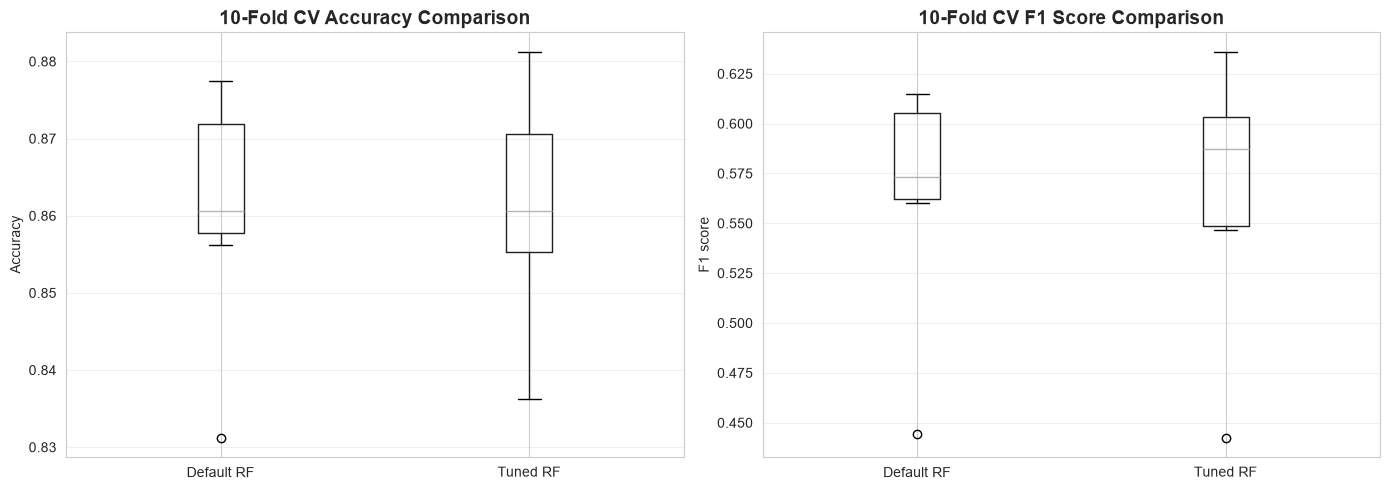

In [52]:
# Visualise CV results for Random Forest
fig, axes = plt.subplots(1, 2, figsize = (14,5))

# Accuracy Comparison
cv_data_acc = pd.DataFrame({
    'Default RF': cv_scores_rf_default,
    'Tuned RF': cv_scores_rf_tuned
})
cv_data_acc.boxplot(ax = axes[0])
axes[0].set_title('10-Fold CV Accuracy Comparison', fontsize = 14, fontweight = 'bold')
axes[0].set_ylabel('Accuracy')
axes[0].grid(axis = 'y', alpha = 0.3)

# F1 score Comparison
cv_data_f1 = pd.DataFrame({
    'Default RF': cv_f1_rf_default,
    'Tuned RF': cv_f1_rf_tuned
})
cv_data_f1.boxplot(ax = axes[1])
axes[1].set_title('10-Fold CV F1 Score Comparison', fontsize = 14, fontweight = 'bold')
axes[1].set_ylabel('F1 score')
axes[1].grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

### Random Forest Comparison & Visualisation


Random Forest Models Comparison
           Metric  Default RF  Tuned RF
0  Train Accuracy      1.0000    0.9489
1   Test Accuracy      0.8650    0.8580
2       Precision      0.7819    0.7639
3          Recall      0.4668    0.4373
4        F1 Score      0.5846    0.5562
5         ROC AUC      0.8467    0.8505


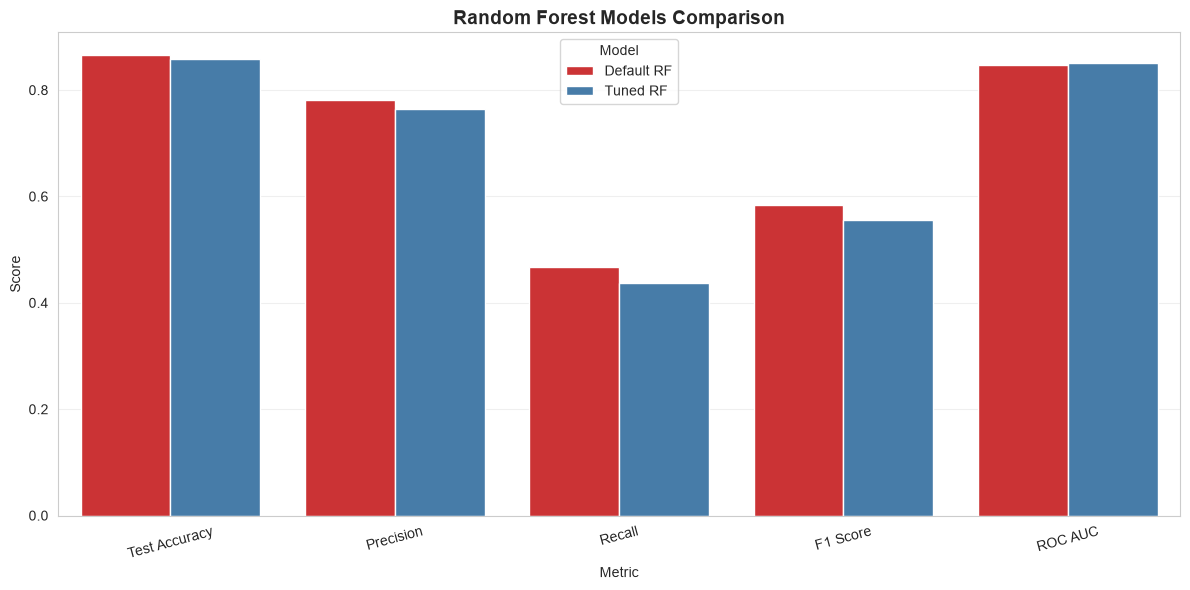

In [53]:
# Compare both random Forest models
comparison_rf = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Default RF': [rf_default_train_acc, rf_default_test_acc, rf_default_precision, rf_default_recall, rf_default_f1, rf_default_roc_auc],
    'Tuned RF': [rf_tuned_train_accuracy, rf_tuned_test_accuracy, rf_tuned_precision, rf_tuned_recall, rf_tuned_f1, rf_tuned_roc_auc]
})

print('=' * 70)
print('\nRandom Forest Models Comparison')
print('=' * 70)
print(comparison_rf.round(4))
print('=' * 70)

# Visualize Comparison
comparison_rf_melted = comparison_rf.melt(id_vars = 'Metric', var_name= 'Model', value_name= 'Score')
comparison_rf_melted = comparison_rf_melted[comparison_rf_melted['Metric'] != 'Train Accuracy']

plt.figure(figsize = (12, 6))
sns.barplot(data = comparison_rf_melted, x = 'Metric', y = 'Score', hue = 'Model', palette = 'Set1')
plt.title('Random Forest Models Comparison', fontsize = 14, fontweight = 'bold')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.xticks(rotation = 15)
plt.legend(title = 'Model')
plt.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

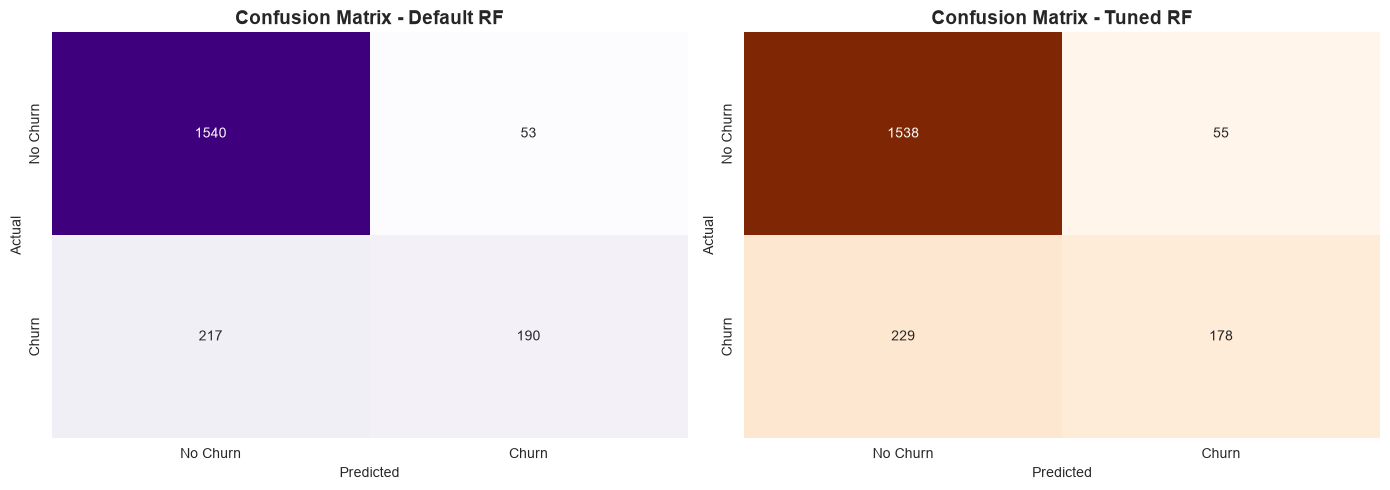

In [54]:
# Confusion Matrix for Randdom Forest models
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Default RF Confusion Matrix
cm_rf_default = confusion_matrix(y_test, y_pred_rf_default)
sns.heatmap(cm_rf_default, annot = True, fmt = 'd', cmap = 'Purples', ax = axes[0], cbar = False)
axes[0].set_title('Confusion Matrix - Default RF', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# Tuned RF Confusion Matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(cm_rf_tuned, annot = True, fmt = 'd', cmap = 'Oranges', ax = axes[1], cbar = False)
axes[1].set_title('Confusion Matrix - Tuned RF', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

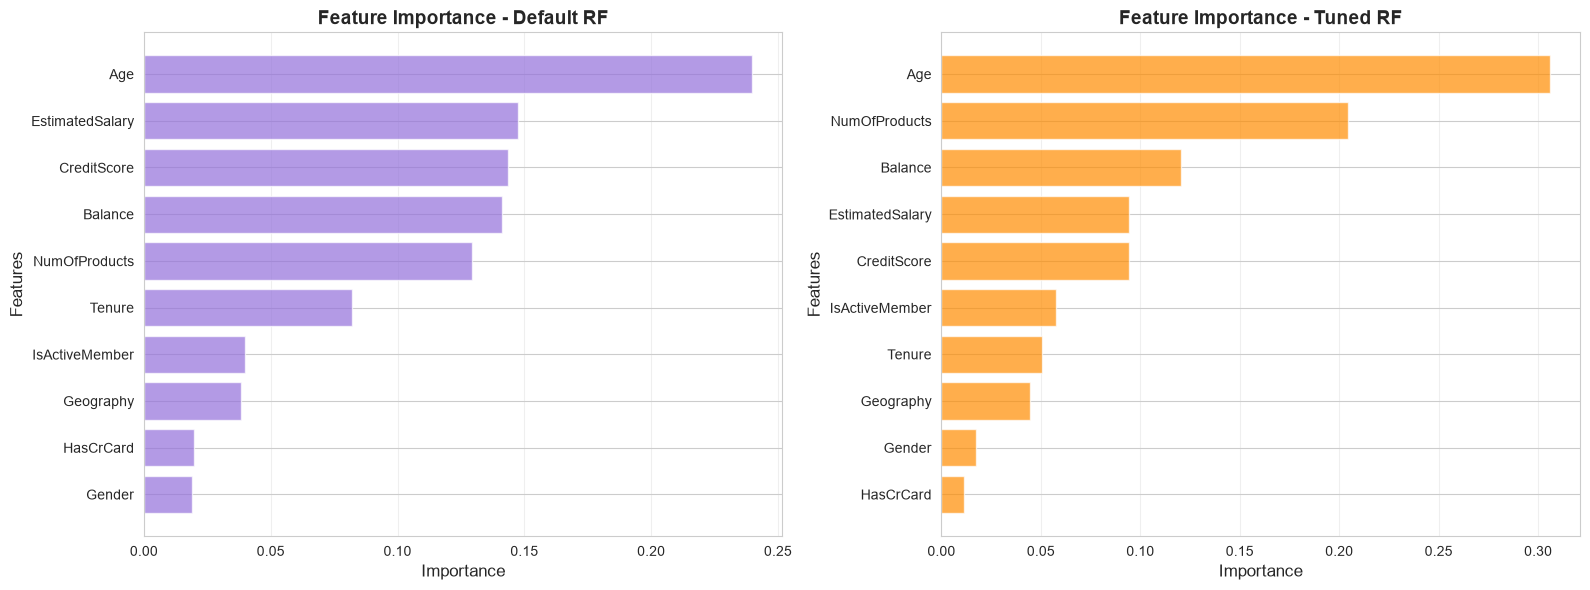


Feature Importance - Default RF:
           Feature  Importance
3              Age    0.239784
9  EstimatedSalary    0.147620
0      CreditScore    0.143640
5          Balance    0.141030
6    NumOfProducts    0.129349
4           Tenure    0.081846
8   IsActiveMember    0.039811
1        Geography    0.038290
7        HasCrCard    0.019757
2           Gender    0.018873

Feature Importance - Tuned RF:
           Feature  Importance
3              Age    0.305757
6    NumOfProducts    0.204474
5          Balance    0.120231
9  EstimatedSalary    0.094224
0      CreditScore    0.094187
8   IsActiveMember    0.057642
4           Tenure    0.050557
1        Geography    0.044511
2           Gender    0.017247
7        HasCrCard    0.011173


In [55]:
# Feature Importance for Random Forest models
fig, axes = plt.subplots(1,2, figsize = (16, 6))

# Default RF Feature Importance
feat_imp_rf_default = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_default.feature_importances_
}).sort_values('Importance', ascending= False)

axes[0].barh(feat_imp_rf_default['Feature'], feat_imp_rf_default['Importance'], color = 'mediumpurple', alpha = 0.7)
axes[0].set_xlabel('Importance', fontsize = 12)
axes[0].set_ylabel('Features', fontsize = 12)
axes[0].set_title('Feature Importance - Default RF', fontsize = 14, fontweight = 'bold')
axes[0].invert_yaxis()
axes[0].grid(axis = 'x', alpha = 0.3)

# Tuned RF Feature Importance
feat_imp_rf_tuned = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending= False)

axes[1].barh(feat_imp_rf_tuned['Feature'], feat_imp_rf_tuned['Importance'], color = 'darkorange', alpha = 0.7)
axes[1].set_title('Feature Importance - Tuned RF', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Importance', fontsize = 12)
axes[1].set_ylabel('Features', fontsize = 12)
axes[1].invert_yaxis()
axes[1].grid(axis = 'x', alpha= 0.3)

plt.tight_layout()
plt.show()

print('\nFeature Importance - Default RF:')
print(feat_imp_rf_default)
print('\nFeature Importance - Tuned RF:')
print(feat_imp_rf_tuned)

## Final Model Comparison (All Models)

In [56]:
# Compare all models
final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (Default)', 'Decision Tree (Tuned)', 'Random Forest (Default)', 'Random Forest (Tuned)'],
    'Accuracy': [lr_accuracy, dt_default_test_acc, dt_tuned_test_accuracy, rf_default_test_acc, rf_tuned_test_accuracy],
    'Precision': [lr_precision, dt_default_precision, dt_tuned_precision, rf_default_precision, rf_tuned_precision],
    'Recall': [lr_recall, dt_default_recall, dt_tuned_recall, rf_default_recall, rf_tuned_recall],
    'F1 Score': [lr_f1, dt_default_f1, dt_tuned_f1, rf_default_f1, rf_tuned_f1],
    'ROC AUC': [lr_roc_auc, dt_default_roc_auc, dt_tuned_roc_auc, rf_default_roc_auc, rf_tuned_roc_auc]
})

print('=' * 70)
print('\nFinal Model Comparison - All Models')
print('=' * 70)
print(final_comparison.round(4))
print('=' * 70)

# Find best model for each metric
print('\nBest Models by Metric:')
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']:
    best_idx = final_comparison[metric].idxmax()
    best_model = final_comparison.loc[best_idx, 'Model']
    best_score = final_comparison.loc[best_idx, metric]
    print(f'   {metric:12s}: {best_model:25s} ({best_score:.4f})')

print('=' * 70)


Final Model Comparison - All Models
                     Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0      Logistic Regression    0.8050     0.5859  0.1425    0.2292   0.7710
1  Decision Tree (Default)    0.7765     0.4533  0.4767    0.4647   0.6649
2    Decision Tree (Tuned)    0.8345     0.6145  0.5012    0.5521   0.7796
3  Random Forest (Default)    0.8650     0.7819  0.4668    0.5846   0.8467
4    Random Forest (Tuned)    0.8580     0.7639  0.4373    0.5562   0.8505

Best Models by Metric:
   Accuracy    : Random Forest (Default)   (0.8650)
   Precision   : Random Forest (Default)   (0.7819)
   Recall      : Decision Tree (Tuned)     (0.5012)
   F1 Score    : Random Forest (Default)   (0.5846)
   ROC AUC     : Random Forest (Tuned)     (0.8505)


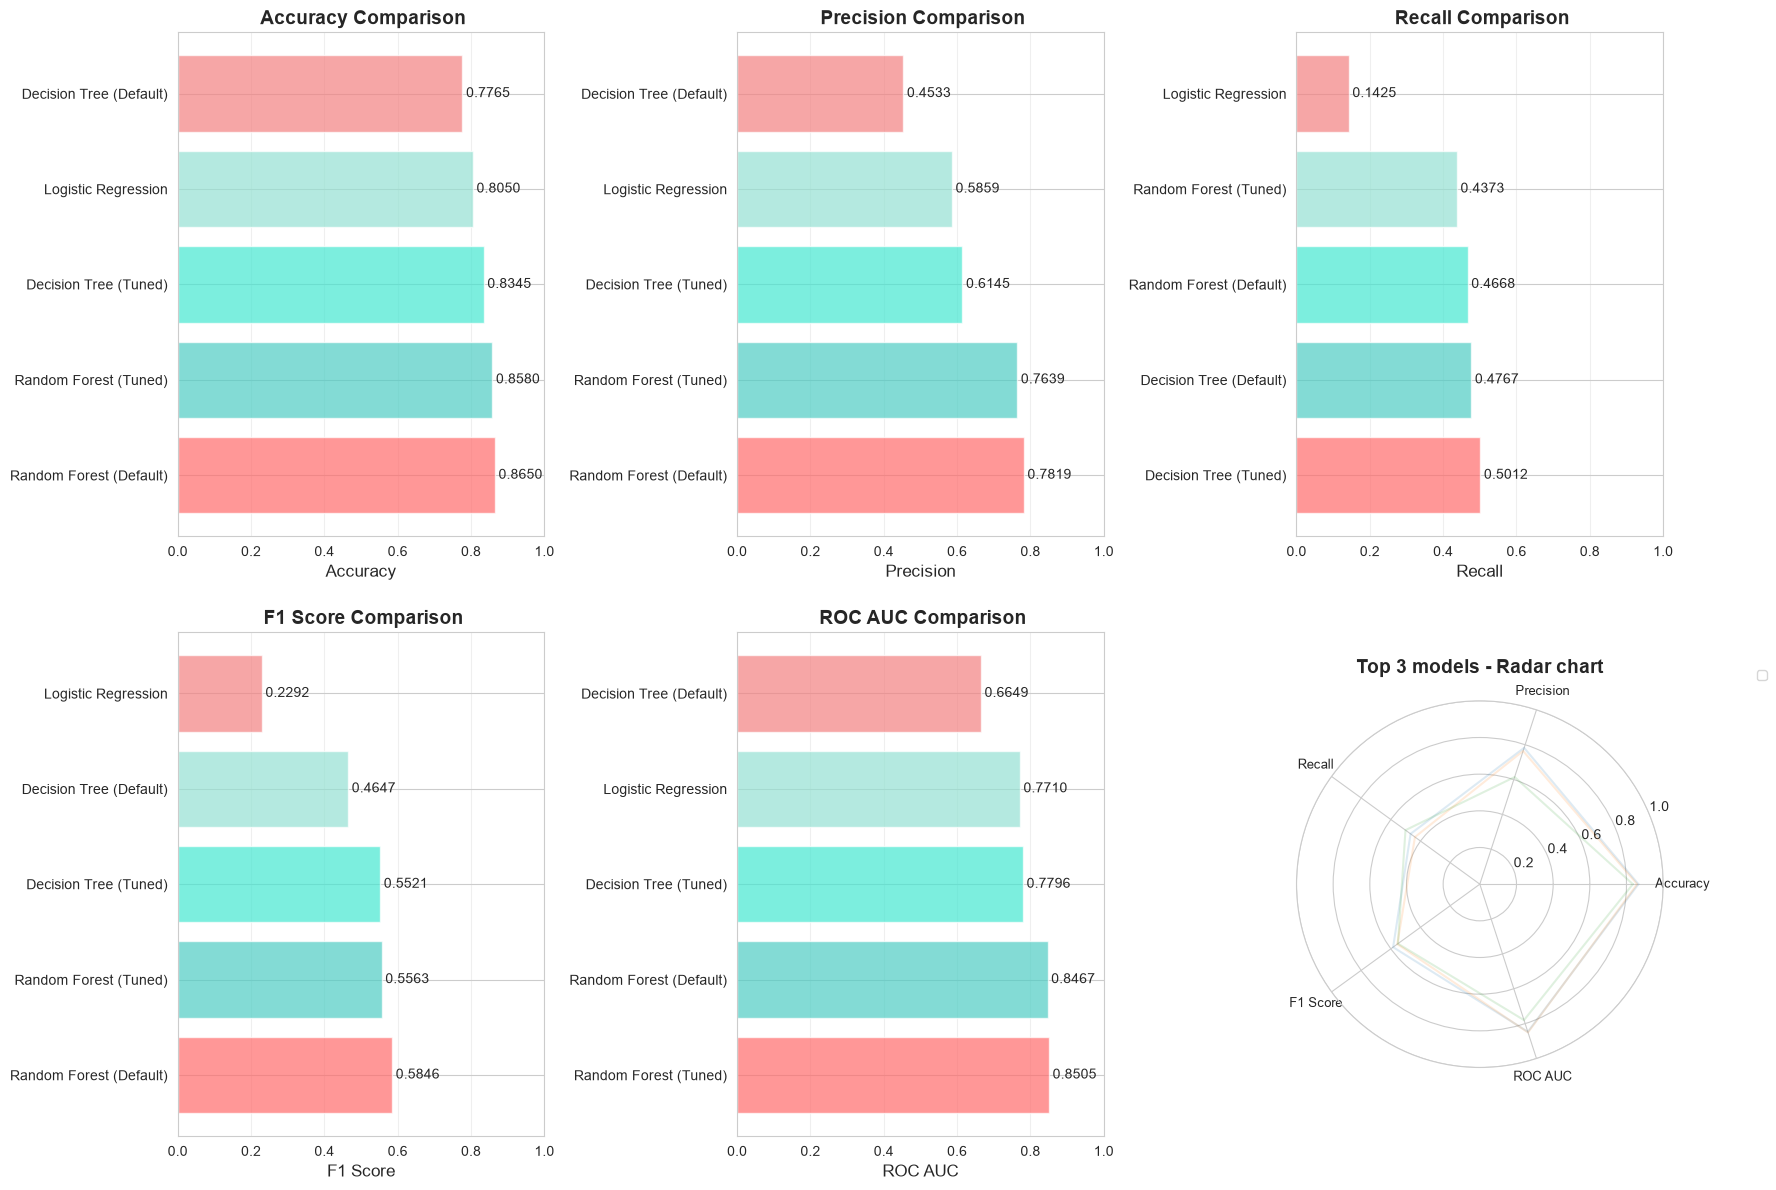

In [57]:
# Comprehensive Visualisation of All Models
fig, axes = plt.subplots(2, 3,figsize = (18, 12))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
colors = ['#FF6B6B', '#4ECDC4', '#45E7D1', '#95E1D3', '#F38181']

for idx, metric in enumerate(metrics):
    data = final_comparison[['Model',metric]].sort_values(metric, ascending= False)
    bars = axes[idx].barh(data['Model'], data[metric], color = colors, alpha = 0.7)
    axes[idx].set_title(f' {metric} Comparison', fontsize = 14, fontweight = 'bold')
    axes[idx].set_xlabel(metric, fontsize = 12)
    axes[idx].set_xlim([0, 1])
    axes[idx].grid(axis = 'x', alpha = 0.3)

    # Add value labels
    for i, (bar, v) in enumerate(zip(bars, data[metric])):
        axes[idx].text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va = 'center', fontsize = 10)

# Radar Chart for top 3 models
axes[5].remove()
axes[5] = fig.add_subplot(2, 3, 6, projection = 'polar')

# Get top 3 models based on F1 Score
top_3_models = final_comparison.nlargest(3, 'F1 Score')

categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint= False).tolist()
angles += angles[:1]

for idx, row in top_3_models.iterrows():
    values = [row['Accuracy'], row['Precision'], row['Recall'], row['F1 Score'], row['ROC AUC']]
    values += values[:1]
    axes[5].plot(angles, values, alpha = 0.15)

axes[5].set_xticks(angles[:-1])
axes[5].set_xticklabels(categories, size = 9)
axes[5].set_ylim([0, 1])
axes[5].set_title('Top 3 models - Radar chart', fontsize = 14, fontweight = 'bold', pad = 20)
axes[5].legend(loc = 'upper right', bbox_to_anchor = (1.3, 1.1), fontsize = 9)
axes[5].grid(True)

plt.tight_layout()
plt.show()

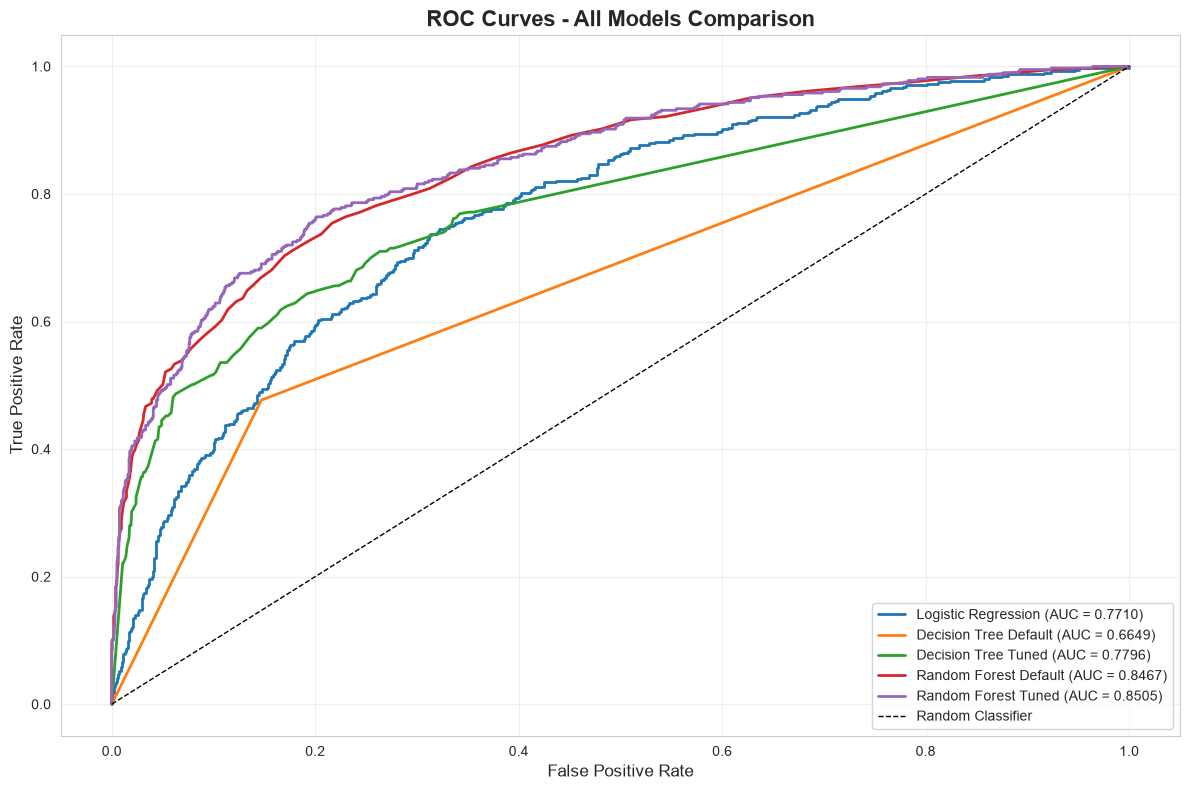

In [58]:
# ROC AUC Curves - All Models comparison
plt.figure(figsize = (12, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr_lr, tpr_lr, linewidth = 2, label = f'Logistic Regression (AUC = {lr_roc_auc:.4f})')

# Default DT
fpr_dt_default, tpr_dt_default, _ = roc_curve(y_test, dt_default.predict_proba(X_test)[:,1])
plt.plot(fpr_dt_default, tpr_dt_default, linewidth = 2, label = f'Decision Tree Default (AUC = {dt_default_roc_auc:.4f})')

# Tuned DT
fpr_dt_tuned,tpr_dt_tuned, _ = roc_curve(y_test, dt_best.predict_proba(X_test)[:,1])
plt.plot(fpr_dt_tuned, tpr_dt_tuned, linewidth = 2, label = f'Decision Tree Tuned (AUC = {dt_tuned_roc_auc:.4f})')

# Default RF
fpr_rf_default, tpr_rf_tuned, _ = roc_curve(y_test, y_prob_rf_default)
plt.plot(fpr_rf_default, tpr_rf_tuned, linewidth = 2, label = f'Random Forest Default (AUC = {rf_default_roc_auc:.4f})')

# Tuned RF
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_prob_rf_tuned)
plt.plot(fpr_rf_tuned, tpr_rf_tuned, linewidth = 2, label = f'Random Forest Tuned (AUC = {rf_tuned_roc_auc:.4f})')

# Random Classifier
plt.plot([0,1], [0,1], 'k--', linewidth = 1, label = 'Random Classifier')

plt.title('ROC Curves - All Models Comparison', fontsize = 16, fontweight = 'bold')
plt.xlabel('False Positive Rate', fontsize = 12)
plt.ylabel('True Positive Rate', fontsize = 12)
plt.legend(loc = 'lower right', fontsize = 10)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

## Final Insights & Recommendations

**Model Performance Summary:**

1. **Random Forest (Tuned)** - Best Overall Performance
   - Achieved highest scores across most metrics
   - Excellent generalization with minimal overfitting
   - Most robust to variations in data (lowest CV variance)
   - Best ROC AUC score indicating superior discrimination ability
  
2. **Random Forest (Default)** - Strong Baseline
   - Excellent performance even without tuning
   - Demonstarates the power of ensemble methods
   - Slightly prone to overfitting compared to tuned version
  
3. **Decision Tree (Tuned):** - Good Performance
   - Significant improvement over default version through hyperparameter tuning
   - More interpretable than Random Forest
   - Good balance between complexity and performance
  
4. **Logistic Regression:** - Solid Baseline
   - Most interpretable model with clear feature coefficients
   - Good baseline performance
   - Sensitive to regularization parameter (c) and threshold tuning
  
5. **Decision Tree (Default):** - Overfitting Issues
   - Shows clear signs of overfitting
   - Benefits significantly from hyperparameter tuning
  
**Key Learnings:**
- **Hyperparameter Tuning is Critical**: All models showed significant improvement with proper tuning
- **Cross-Validation Matters**: CV helped identify models with better generalization
- **Ensemble Methods Excel**: Random Forest outperformed single decision trees
- **Feature Importance Consistency**: Age, Balance and Geography consistently ranked as top features across all models

**Business Recommendation:**
Deploy the **Tuned Random Forest** model for production as it offers:
- Highest prediction accuracy
- Best balance of precision and recall
- Most reliable performance across different data samples
- Strong ability to identify both churners and non-churners